# QuickBite ETL Pipeline — Big Data Final Exam

---
## Section 0 — Environment Setup

In [1]:
!pip install pyspark matplotlib numpy pandas --quiet


[notice] A new release of pip is available: 26.0.1 -> 26.1.2
[notice] To update, run: C:\Users\Vivtus\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


In [2]:
import os
import pandas as pd
from difflib import get_close_matches

from pyspark.sql import SparkSession
from pyspark.sql import functions as F
from pyspark.sql.types import (
    StructType, StructField, StringType, IntegerType,
    DoubleType, TimestampType, DateType
)
from pyspark.sql.window import Window

In [3]:
spark = (
    SparkSession.builder
    .appName("QuickBite_ETL")
    .config("spark.sql.adaptive.enabled", "true")
    .config("spark.sql.adaptive.coalescePartitions.enabled", "true")
    .config("spark.sql.shuffle.partitions", "8")
    .getOrCreate()
)
spark.sparkContext.setLogLevel("WARN")
print( spark.version)

4.1.1


### 0.1 — Locate CSV Files

The notebook searches both the current working directory and `data/` so it runs
identically on Colab (flat upload) and locally (files in `data/`).

In [ ]:
FILE_NAMES = [
    "app_events.csv", "orders.csv", "payments.csv",
    "restaurants.csv", "couriers.csv",
    "marketing_campaigns.csv", "promo_codes.csv",
]

def resolve_path(filename):
    for candidate in [filename, os.path.join("data", filename)]:
        if os.path.exists(candidate):
            return os.path.abspath(candidate)
    raise FileNotFoundError(f"{filename} not found in cwd or data/")

paths = {name: resolve_path(name) for name in FILE_NAMES}
print("Resolved file paths:")
for name, path in paths.items():
    size_kb = os.path.getsize(path) / 1024
    print(f"  {name:<30s} -> {path}  ({size_kb:,.1f} KB)")

### 0.2 — Load DataFrames

All CSVs are read with `inferSchema=False` (every column lands as `StringType`).
Timestamp and date columns are cast explicitly with `to_timestamp` / `to_date`
so Section 1 temporal comparisons operate on true `TimestampType`.
Numeric columns are cast individually.  `orders`, `app_events`, and `payments`
are cached because they appear in many downstream actions.

In [5]:
def read_csv_raw(path):
    # pandas reader bypasses Hadoop/HDFS — works on any Java version locally.
    # dtype=object keeps every non-null value as a plain Python str (matches
    # inferSchema=False) while avoiding pd.StringDtype's NA representation,
    # which survives .where() and produces literal "nan" strings in Spark.
    _pdf = pd.read_csv(path, dtype=object, keep_default_na=True, na_values=[""])
    return spark.createDataFrame(_pdf.where(_pdf.notna(), None))

app_events = (
    read_csv_raw(paths["app_events.csv"])
    .withColumn("ts", F.to_timestamp("ts"))
    .cache()
)

orders = (
    read_csv_raw(paths["orders.csv"])
    .withColumn("subtotal",     F.col("subtotal").cast(DoubleType()))
    .withColumn("discount",     F.col("discount").cast(DoubleType()))
    .withColumn("total",        F.col("total").cast(DoubleType()))
    .withColumn("rating",       F.col("rating").cast(DoubleType()))
    .withColumn("placed_ts",    F.to_timestamp("placed_ts"))
    .withColumn("accepted_ts",  F.to_timestamp("accepted_ts"))
    .withColumn("picked_up_ts", F.to_timestamp("picked_up_ts"))
    .withColumn("delivered_ts", F.to_timestamp("delivered_ts"))
    .cache()
)

payments = (
    read_csv_raw(paths["payments.csv"])
    .withColumn("amount", F.col("amount").cast(DoubleType()))
    .withColumn("ts",     F.to_timestamp("ts"))
    .cache()
)

restaurants = (
    read_csv_raw(paths["restaurants.csv"])
    .withColumn("avg_prep_minutes", F.col("avg_prep_minutes").cast(IntegerType()))
    .withColumn("rating_avg",       F.col("rating_avg").cast(DoubleType()))
    .withColumn("signup_date",      F.to_date("signup_date"))
)

couriers = (
    read_csv_raw(paths["couriers.csv"])
    .withColumn("shift_start_hour", F.col("shift_start_hour").cast(IntegerType()))
    .withColumn("shift_end_hour",   F.col("shift_end_hour").cast(IntegerType()))
)

marketing_campaigns = (
    read_csv_raw(paths["marketing_campaigns.csv"])
    .withColumn("budget",   F.col("budget").cast(DoubleType()))
    .withColumn("start_ts", F.to_timestamp("start_ts"))
    .withColumn("end_ts",   F.to_timestamp("end_ts"))
)

promo_codes = (
    read_csv_raw(paths["promo_codes.csv"])
    .withColumn("discount_pct",  F.col("discount_pct").cast(DoubleType()))
    .withColumn("max_uses",      F.col("max_uses").cast(IntegerType()))
    .withColumn("current_uses",  F.col("current_uses").cast(IntegerType()))
    .withColumn("valid_from",    F.to_date("valid_from"))
    .withColumn("valid_to",      F.to_date("valid_to"))
)

TABLES = {
    "app_events":          app_events,
    "orders":              orders,
    "payments":            payments,
    "restaurants":         restaurants,
    "couriers":            couriers,
    "marketing_campaigns": marketing_campaigns,
    "promo_codes":         promo_codes,
}

print("Row counts and schemas")
for tname, df in TABLES.items():
    cnt = df.count()
    print(f"  {tname}  ({cnt:,} rows)")
    df.printSchema()

Row counts and schemas


  app_events  (80,000 rows)
root
 |-- event_id: string (nullable = true)
 |-- user_id: string (nullable = true)
 |-- session_id: string (nullable = true)
 |-- event_type: string (nullable = true)
 |-- screen: string (nullable = true)
 |-- device: string (nullable = true)
 |-- app_version: string (nullable = true)
 |-- ts: timestamp (nullable = true)
 |-- city: string (nullable = true)



  orders  (15,000 rows)
root
 |-- order_id: string (nullable = true)
 |-- customer_id: string (nullable = true)
 |-- restaurant_id: string (nullable = true)
 |-- courier_id: string (nullable = true)
 |-- status: string (nullable = true)
 |-- subtotal: double (nullable = true)
 |-- discount: double (nullable = true)
 |-- total: double (nullable = true)
 |-- promo_code: string (nullable = true)
 |-- placed_ts: timestamp (nullable = true)
 |-- accepted_ts: timestamp (nullable = true)
 |-- picked_up_ts: timestamp (nullable = true)
 |-- delivered_ts: timestamp (nullable = true)
 |-- rating: double (nullable = true)
 |-- city: string (nullable = true)



  payments  (14,827 rows)
root
 |-- payment_id: string (nullable = true)
 |-- order_id: string (nullable = true)
 |-- method: string (nullable = true)
 |-- amount: double (nullable = true)
 |-- status: string (nullable = true)
 |-- ts: timestamp (nullable = true)
 |-- gateway_ref: string (nullable = true)



  restaurants  (500 rows)
root
 |-- restaurant_id: string (nullable = true)
 |-- name: string (nullable = true)
 |-- cuisine: string (nullable = true)
 |-- city: string (nullable = true)
 |-- is_available: string (nullable = true)
 |-- avg_prep_minutes: integer (nullable = true)
 |-- rating_avg: double (nullable = true)
 |-- signup_date: date (nullable = true)



  couriers  (300 rows)
root
 |-- courier_id: string (nullable = true)
 |-- name: string (nullable = true)
 |-- vehicle: string (nullable = true)
 |-- city: string (nullable = true)
 |-- shift_start_hour: integer (nullable = true)
 |-- shift_end_hour: integer (nullable = true)
 |-- is_active: string (nullable = true)



  marketing_campaigns  (50 rows)
root
 |-- campaign_id: string (nullable = true)
 |-- name: string (nullable = true)
 |-- channel: string (nullable = true)
 |-- target_segment: string (nullable = true)
 |-- start_ts: timestamp (nullable = true)
 |-- end_ts: timestamp (nullable = true)
 |-- budget: double (nullable = true)



  promo_codes  (210 rows)
root
 |-- code: string (nullable = true)
 |-- campaign_id: string (nullable = true)
 |-- discount_pct: double (nullable = true)
 |-- max_uses: integer (nullable = true)
 |-- current_uses: integer (nullable = true)
 |-- valid_from: date (nullable = true)
 |-- valid_to: date (nullable = true)



---
## Section 1 — Data Quality Detection

All counts are computed from the actual data — nothing is assumed or hardcoded.
Every category covers every relevant table; where a table is clean I say so explicitly.

Status detection is data-driven: a value is flagged when `LOWER(TRIM(raw))` doesn't match the canonical set, or when the raw form differs from what normalization produces. No hardcoded bad-value lists.

Categories: duplicates, referential integrity, enum validity, temporal ordering, range validity, cross-table reconciliation, and logical consistency. Two issues are intentionally left unfixed — the reasoning is in the cells below.

In [6]:
# ── Canonical status set — single source of truth used throughout ─────────────
CANONICAL_STATUSES = frozenset({
    "pending","accepted","rejected","preparing","picked_up","delivered","cancelled"
})

# Data-driven non-canonical mask:
#   (a) LOWER(TRIM(raw)) not in canonical set  -> typos like "delivrd"
#   (b) raw != LOWER(TRIM(raw))                -> casing like "DELIVERED", "Delivered"
non_canonical_status = (
    ~F.lower(F.trim(F.col("status"))).isin(list(CANONICAL_STATUSES)) |
    (F.col("status") != F.lower(F.trim(F.col("status"))))
)

# ── Shared helpers ────────────────────────────────────────────────────────────
def pct(bad, total):
    return f"{100.0 * bad / total:.2f} %" if total else "N/A"

def ok_or_issue(n, label=""):
    tag = "CLEAN" if n == 0 else f"ISSUE ({n:,} rows)"
    return f"{label}  {tag}" if label else tag

def check_pk_uniqueness(df, pk_col, table_name):
    total = df.count()
    row = (
        df.groupBy(pk_col).count()
        .filter(F.col("count") > 1)
        .agg(F.sum("count").alias("dup_rows"), F.count("*").alias("dup_keys"))
        .collect()[0]
    )
    dup_rows = int(row["dup_rows"]) if row["dup_rows"] else 0
    dup_keys = int(row["dup_keys"]) if row["dup_keys"] else 0
    if dup_rows == 0:
        print(f"  [{table_name}.{pk_col}]  CLEAN  (total: {total:,})")
    else:
        print(f"  [{table_name}.{pk_col}]  ISSUE: {dup_rows} rows across {dup_keys} dup keys  (total: {total:,})")
    return dup_rows, total

def check_enum(df, col_name, valid_set, table_name):
    # Print all distinct values; flag those outside valid_set. Fully data-driven.
    total = df.count()
    dist = df.groupBy(col_name).count().orderBy(F.col("count").desc()).collect()
    print(f"\n  [{table_name}.{col_name}]  valid={sorted(valid_set)}")
    bad = 0
    for row in dist:
        val  = row[col_name]
        cnt  = row["count"]
        flag = "" if (val in valid_set) else "  <- INVALID"
        print(f"    {repr(val):<28s} {cnt:>8,}{flag}")
        if val not in valid_set:
            bad += cnt
    print(f"  Invalid rows: {bad:,} / {total:,}  ({pct(bad, total)})")
    return bad, total

def check_fk(child_df, child_col, parent_df, parent_col, label, nullable=False):
    src   = child_df.filter(F.col(child_col).isNotNull()) if nullable else child_df
    total = src.count()
    keys  = parent_df.select(F.col(parent_col).alias("__k__")).distinct()
    bad   = src.join(keys, src[child_col] == keys["__k__"], "left_anti").count()
    if bad == 0:
        print(f"  [{label}]  CLEAN")
    else:
        print(f"  [{label}]  ISSUE: {bad:,} orphan rows ({pct(bad, total)})")
    return bad, total

print("Helpers defined.  CANONICAL_STATUSES:", sorted(CANONICAL_STATUSES))

Helpers defined.  CANONICAL_STATUSES: ['accepted', 'cancelled', 'delivered', 'pending', 'picked_up', 'preparing', 'rejected']


---
### Category 1 — Duplicates / PK Uniqueness

Checked every primary key for duplicates across all seven tables.
Also checked `gateway_ref` in payments — duplicate refs mean the same external transaction was recorded twice.

**Team impact:** Finance sees double-counted revenue; duplicate `order_id` rows corrupt every per-order metric across Product, Couriers, and Support.

In [7]:

print("CATEGORY 1: Duplicates / PK Uniqueness")

pk_checks = [
    (app_events,          "event_id",      "app_events"),
    (orders,              "order_id",      "orders"),
    (payments,            "payment_id",    "payments"),
    (restaurants,         "restaurant_id", "restaurants"),
    (couriers,            "courier_id",    "couriers"),
    (promo_codes,         "code",          "promo_codes"),
    (marketing_campaigns, "campaign_id",   "marketing_campaigns"),
]
pk_results = {}
for df, col, tbl in pk_checks:
    bad, tot = check_pk_uniqueness(df, col, tbl)
    pk_results[tbl] = (bad, tot)

# gateway_ref: should be unique per transaction row
gw_row = (
    payments.filter(F.col("gateway_ref").isNotNull())
    .groupBy("gateway_ref").count()
    .filter(F.col("count") > 1)
    .agg(F.sum("count").alias("dup_rows")).collect()[0]
)
gw_bad = int(gw_row["dup_rows"]) if gw_row["dup_rows"] else 0
print(f"  [payments.gateway_ref]  {ok_or_issue(gw_bad)}")

print("\nCategory 1 result: all PKs unique, gateway_ref unique.")

CATEGORY 1: Duplicates / PK Uniqueness


  [app_events.event_id]  CLEAN  (total: 80,000)


  [orders.order_id]  CLEAN  (total: 15,000)


  [payments.payment_id]  CLEAN  (total: 14,827)


  [restaurants.restaurant_id]  CLEAN  (total: 500)


  [couriers.courier_id]  CLEAN  (total: 300)


  [promo_codes.code]  CLEAN  (total: 210)


  [marketing_campaigns.campaign_id]  CLEAN  (total: 50)


  [payments.gateway_ref]  CLEAN

Category 1 result: all PKs unique, gateway_ref unique.


---
### Category 2 — Referential Integrity

Each FK tested with a left-anti join against the parent PK. Nullable FKs (`courier_id`, `promo_code`) are filtered to non-null rows first.

**Team impact:** Orphan `customer_id` breaks Product's funnel join to app_events; orphan `promo_code` means Marketing cannot attribute discounts to campaigns; orphan `courier_id` drops deliveries from Courier performance tables.

In [8]:

print("CATEGORY 2: Referential Integrity")

fk_results = {}
fk_results["orders.customer_id"]   = check_fk(orders,     "customer_id",   app_events,          "user_id",       "orders.customer_id -> app_events.user_id")
fk_results["orders.restaurant_id"] = check_fk(orders,     "restaurant_id", restaurants,         "restaurant_id", "orders.restaurant_id -> restaurants.restaurant_id")
fk_results["orders.courier_id"]    = check_fk(orders,     "courier_id",    couriers,            "courier_id",    "orders.courier_id -> couriers.courier_id (nullable)",   nullable=True)
fk_results["orders.promo_code"]    = check_fk(orders,     "promo_code",    promo_codes,         "code",          "orders.promo_code -> promo_codes.code (nullable)",       nullable=True)
fk_results["payments.order_id"]    = check_fk(payments,   "order_id",      orders,              "order_id",      "payments.order_id -> orders.order_id")
fk_results["promos.campaign_id"]   = check_fk(promo_codes,"campaign_id",   marketing_campaigns, "campaign_id",   "promo_codes.campaign_id -> campaigns.campaign_id")

print("\nOrphan promo_codes detail:")
(
    promo_codes
    .join(marketing_campaigns.select("campaign_id").distinct(), "campaign_id", "left_anti")
    .select("code","campaign_id","discount_pct","max_uses","current_uses")
    .show(truncate=False)
)

CATEGORY 2: Referential Integrity


  [orders.customer_id -> app_events.user_id]  CLEAN


  [orders.restaurant_id -> restaurants.restaurant_id]  CLEAN


  [orders.courier_id -> couriers.courier_id (nullable)]  CLEAN


  [orders.promo_code -> promo_codes.code (nullable)]  CLEAN


  [payments.order_id -> orders.order_id]  CLEAN


  [promo_codes.campaign_id -> campaigns.campaign_id]  ISSUE: 10 orphan rows (4.76 %)

Orphan promo_codes detail:


+--------+-----------+------------+--------+------------+
|code    |campaign_id|discount_pct|max_uses|current_uses|
+--------+-----------+------------+--------+------------+
|DL9FC1XX|CMP9000    |20.0        |100     |7           |
|6AKT7ZQH|CMP9002    |20.0        |100     |79          |
|99259P5Z|CMP9001    |15.0        |100     |40          |
|1FB2VI10|CMP9005    |20.0        |100     |14          |
|MK2ZYZSI|CMP9008    |15.0        |100     |66          |
|04JSE17Q|CMP9006    |20.0        |100     |0           |
|Q929U6WT|CMP9007    |20.0        |100     |29          |
|U3NDZ3CC|CMP9009    |10.0        |100     |60          |
|2XZ52OHK|CMP9003    |10.0        |100     |68          |
|M00E9KDT|CMP9004    |20.0        |100     |43          |
+--------+-----------+------------+--------+------------+



---
### Category 3 — Enum Validity and Normalization

Status values are flagged when `LOWER(TRIM(raw))` is not in the canonical set, or when the raw form already differs from normalized — fully data-driven, no hardcoded bad-value list.

**Team impact:** Non-canonical status values cause every status-based filter to silently miss rows — Product's funnel under-counts completions, Finance's revenue sum skips delivered orders, Couriers' on-time rate drops, Support's late-delivery detection misfires.

In [9]:

print("CATEGORY 3: Enum Validity / Normalization")


ord_total = orders.count()

# ── orders.status: data-driven full distribution 
print("\n  [orders.status] — all distinct raw values with canonical flag:")
status_dist = (
    orders
    .groupBy("status")
    .agg(F.count("*").alias("cnt"))
    .withColumn("normalized",    F.lower(F.trim(F.col("status"))))
    .withColumn("in_canonical",  F.lower(F.trim(F.col("status"))).isin(list(CANONICAL_STATUSES)))
    .withColumn("already_clean", F.col("status") == F.lower(F.trim(F.col("status"))))
    .withColumn("is_canonical",
        F.lower(F.trim(F.col("status"))).isin(list(CANONICAL_STATUSES)) &
        (F.col("status") == F.lower(F.trim(F.col("status")))))
    .orderBy(F.col("cnt").desc())
)
status_dist.show(20, truncate=False)

bad_status_cnt = orders.filter(non_canonical_status).count()
print(f"Non-canonical rows (data-driven): {bad_status_cnt:,} / {ord_total:,}  ({pct(bad_status_cnt, ord_total)})")

# ── All other enum columns 
VALID_EVENT_TYPE = {"app_open","search","view_restaurant","add_to_cart","checkout","order_placed"}
VALID_DEVICE     = {"ios","android","web"}
VALID_PAY_METHOD = {"card","wallet","cash"}
VALID_PAY_STATUS = {"success","failed","refunded"}
VALID_VEHICLE    = {"bike","car","scooter"}
VALID_CHANNEL    = {"push","email","code"}
VALID_SEGMENT    = {"new","returning","lapsed","all"}

enum_results = {}
for df, col, vs, tbl in [
    (app_events,          "event_type",     VALID_EVENT_TYPE, "app_events"),
    (app_events,          "device",         VALID_DEVICE,     "app_events"),
    (payments,            "method",         VALID_PAY_METHOD, "payments"),
    (payments,            "status",         VALID_PAY_STATUS, "payments"),
    (couriers,            "vehicle",        VALID_VEHICLE,    "couriers"),
    (marketing_campaigns, "channel",        VALID_CHANNEL,    "marketing_campaigns"),
    (marketing_campaigns, "target_segment", VALID_SEGMENT,    "marketing_campaigns"),
]:
    bad, tot = check_enum(df, col, vs, tbl)
    enum_results[f"{tbl}.{col}"] = (bad, tot)

print("\nCategory 3 SUMMARY: orders.status has non-canonical rows (see above);")
print("all other enum columns are CLEAN.")

CATEGORY 3: Enum Validity / Normalization



  [orders.status] — all distinct raw values with canonical flag:


+---------+-----+----------+------------+-------------+------------+
|status   |cnt  |normalized|in_canonical|already_clean|is_canonical|
+---------+-----+----------+------------+-------------+------------+
|delivered|11846|delivered |true        |true         |true        |
|cancelled|691  |cancelled |true        |true         |true        |
|rejected |664  |rejected  |true        |true         |true        |
|accepted |496  |accepted  |true        |true         |true        |
|preparing|460  |preparing |true        |true         |true        |
|picked_up|436  |picked_up |true        |true         |true        |
|pending  |328  |pending   |true        |true         |true        |
|delivrd  |31   |delivrd   |false       |true         |false       |
|DELIVERED|24   |delivered |true        |false        |false       |
|Delivered|24   |delivered |true        |false        |false       |
+---------+-----+----------+------------+-------------+------------+



Non-canonical rows (data-driven): 79 / 15,000  (0.53 %)



  [app_events.event_type]  valid=['add_to_cart', 'app_open', 'checkout', 'order_placed', 'search', 'view_restaurant']
    'app_open'                     23,889
    'view_restaurant'              20,006
    'search'                       12,233
    'add_to_cart'                  11,826
    'checkout'                      6,439
    'order_placed'                  5,607
  Invalid rows: 0 / 80,000  (0.00 %)


...


  [payments.method]  valid=['card', 'cash', 'wallet']
    'card'                          9,596
    'wallet'                        3,680
    'cash'                          1,551
  Invalid rows: 0 / 14,827  (0.00 %)



  [payments.status]  valid=['failed', 'refunded', 'success']
    'success'                      12,382
    'refunded'                      1,458
    'failed'                          987
  Invalid rows: 0 / 14,827  (0.00 %)



  [couriers.vehicle]  valid=['bike', 'car', 'scooter']
    'scooter'                         120
    'bike'                             95
    'car'                              85
  Invalid rows: 0 / 300  (0.00 %)



  [marketing_campaigns.channel]  valid=['code', 'email', 'push']
    'push'                             18
    'email'                            18
    'code'                             14
  Invalid rows: 0 / 50  (0.00 %)



  [marketing_campaigns.target_segment]  valid=['all', 'lapsed', 'new', 'returning']
    'returning'                        17
    'new'                              14
    'all'                              12
    'lapsed'                            7
  Invalid rows: 0 / 50  (0.00 %)

Category 3 SUMMARY: orders.status has non-canonical rows (see above);
all other enum columns are CLEAN.


---
### Category 4 — Temporal Sanity

Order lifecycle must satisfy `placed_ts <= accepted_ts <= picked_up_ts <= delivered_ts`. Any inversion indicates clock drift, a pipeline bug, or a bad manual back-fill. Payment timestamps and promo/campaign validity windows are also checked.

**Team impact:** Inversions produce negative delivery and prep durations — Couriers' SLA monitoring and avg-delivery-time metric become meaningless; Restaurants' actual prep-time accuracy comparison is corrupted.

In [10]:

print("CATEGORY 4: Temporal Sanity")


ord_total = orders.count()

pl_gt_ac = orders.filter(
    F.col("accepted_ts").isNotNull() & (F.col("accepted_ts") < F.col("placed_ts"))
).count()

ac_gt_pu = orders.filter(
    F.col("picked_up_ts").isNotNull() & F.col("accepted_ts").isNotNull() &
    (F.col("picked_up_ts") < F.col("accepted_ts"))
).count()

pu_gt_de = orders.filter(
    F.col("delivered_ts").isNotNull() & F.col("picked_up_ts").isNotNull() &
    (F.col("delivered_ts") < F.col("picked_up_ts"))
).count()

print(f"  accepted_ts  < placed_ts    : {pl_gt_ac:>6,}  ({pct(pl_gt_ac, ord_total)})  {ok_or_issue(pl_gt_ac)}")
print(f"  picked_up_ts < accepted_ts  : {ac_gt_pu:>6,}  ({pct(ac_gt_pu, ord_total)})  {ok_or_issue(ac_gt_pu)}")
print(f"  delivered_ts < picked_up_ts : {pu_gt_de:>6,}  ({pct(pu_gt_de, ord_total)})  {ok_or_issue(pu_gt_de)}")

print("\nSample: picked_up_ts < accepted_ts")
orders.filter(
    F.col("picked_up_ts").isNotNull() & F.col("accepted_ts").isNotNull() &
    (F.col("picked_up_ts") < F.col("accepted_ts"))
).select("order_id","status","accepted_ts","picked_up_ts").show(5, truncate=False)

print("Sample: delivered_ts < picked_up_ts")
orders.filter(
    F.col("delivered_ts").isNotNull() & F.col("picked_up_ts").isNotNull() &
    (F.col("delivered_ts") < F.col("picked_up_ts"))
).select("order_id","status","picked_up_ts","delivered_ts").show(5, truncate=False)

pay_before = (
    payments
    .join(orders.select("order_id", F.col("placed_ts").alias("opl")), "order_id", "left")
    .filter(F.col("opl").isNotNull() & F.col("ts").isNotNull() & (F.col("ts") < F.col("opl")))
    .count()
)
bad_promo_win = promo_codes.filter(F.col("valid_from") > F.col("valid_to")).count()
bad_camp_win  = marketing_campaigns.filter(F.col("start_ts") > F.col("end_ts")).count()
print(f"  payments.ts < order.placed_ts : {pay_before:>6,}  {ok_or_issue(pay_before)}")
print(f"  promo valid_from > valid_to   : {bad_promo_win:>6,}  {ok_or_issue(bad_promo_win)}")
print(f"  campaign start_ts > end_ts    : {bad_camp_win:>6,}  {ok_or_issue(bad_camp_win)}")

CATEGORY 4: Temporal Sanity


  accepted_ts  < placed_ts    :      0  (0.00 %)  CLEAN
  picked_up_ts < accepted_ts  :     33  (0.22 %)  ISSUE (33 rows)
  delivered_ts < picked_up_ts :     65  (0.43 %)  ISSUE (65 rows)

Sample: picked_up_ts < accepted_ts


+--------+---------+--------------------------+--------------------------+
|order_id|status   |accepted_ts               |picked_up_ts              |
+--------+---------+--------------------------+--------------------------+
|O0000101|delivered|2026-05-15 19:33:18.822028|2026-04-28 23:57:44.125372|
|O0001345|delivered|2026-04-23 09:34:22.659037|2026-04-15 04:28:52.454676|
|O0002112|delivered|2026-04-12 17:33:12.082862|2026-03-30 14:17:26.037127|
|O0002610|delivered|2026-05-11 17:22:30.035144|2026-04-10 10:56:45.638465|
|O0002916|delivered|2026-05-21 08:20:40.910531|2026-04-15 19:23:56.32782 |
+--------+---------+--------------------------+--------------------------+
only showing top 5 rows
Sample: delivered_ts < picked_up_ts


+--------+---------+--------------------------+--------------------------+
|order_id|status   |picked_up_ts              |delivered_ts              |
+--------+---------+--------------------------+--------------------------+
|O0000345|delivered|2026-05-09 15:42:30.170823|2026-05-09 10:43:30.170823|
|O0000484|delivered|2026-04-06 15:55:44.227481|2026-04-06 15:23:44.227481|
|O0000568|delivered|2026-04-16 05:11:46.912675|2026-04-16 04:50:46.912675|
|O0000842|delivered|2026-04-09 22:27:33.046171|2026-04-09 21:57:33.046171|
|O0000915|delivered|2026-04-01 23:05:43.063875|2026-04-01 02:45:43.063875|
+--------+---------+--------------------------+--------------------------+
only showing top 5 rows


  payments.ts < order.placed_ts :      0  CLEAN
  promo valid_from > valid_to   :      0  CLEAN
  campaign start_ts > end_ts    :      0  CLEAN


---
### Category 5 — Range / Value Validity

Numeric columns checked against expected bounds: rating in [1,5]; discount non-negative and at most subtotal; total approximately equal to subtotal minus discount; payment amounts non-negative; discount percentages in [0,100]; shift hours in [0,23]; restaurant prep times for rough plausibility.

**Team impact:** Out-of-range ratings bias Restaurants' leaderboard and NPS proxy; math errors in `total` directly mis-state Finance's GMV; over-range `discount_pct` inflates Marketing's reported discount cost.

In [11]:

print("CATEGORY 5: Range / Value Validity")


ord_total   = orders.count()
pay_total   = payments.count()
promo_total = promo_codes.count()
rest_total  = restaurants.count()
cour_total  = couriers.count()

# orders.rating
bad_rating_rng  = orders.filter(F.col("rating").isNotNull() & ((F.col("rating") < 1) | (F.col("rating") > 5))).count()
null_rating_all = orders.filter(F.col("rating").isNull()).count()
del_total       = orders.filter(F.lower(F.trim(F.col("status"))) == "delivered").count()
null_rating_del = orders.filter((F.lower(F.trim(F.col("status"))) == "delivered") & F.col("rating").isNull()).count()

print(f"\n  [orders.rating]")
print(f"    out-of-range [1,5]            : {bad_rating_rng:,}   {ok_or_issue(bad_rating_rng)}")
print(f"    NULL (all orders)             : {null_rating_all:,} / {ord_total:,}  ({pct(null_rating_all, ord_total)})")
print(f"    NULL on delivered orders      : {null_rating_del:,} / {del_total:,}  ({pct(null_rating_del, del_total)})  <- NOTE")

# orders financials
bad_disc_neg   = orders.filter(F.col("discount") < 0).count()
bad_disc_gt_st = orders.filter(F.col("discount") > F.col("subtotal")).count()
bad_math       = orders.filter(
    F.abs(F.col("subtotal") - F.coalesce(F.col("discount"), F.lit(0.0)) - F.col("total")) > 0.01
).count()

print(f"\n  [orders financials]")
print(f"    discount < 0                  : {bad_disc_neg:,}   {ok_or_issue(bad_disc_neg)}")
print(f"    discount > subtotal           : {bad_disc_gt_st:,}   {ok_or_issue(bad_disc_gt_st)}")
print(f"    subtotal-discount != total    : {bad_math:,} / {ord_total:,}  ({pct(bad_math, ord_total)})   {ok_or_issue(bad_math)}")

print("\nSample total-math violations:")
orders.filter(
    F.abs(F.col("subtotal") - F.coalesce(F.col("discount"), F.lit(0.0)) - F.col("total")) > 0.01
).select(
    "order_id","subtotal","discount","total",
    F.round(F.col("subtotal") - F.coalesce(F.col("discount"),F.lit(0.0)) - F.col("total"), 2).alias("diff")
).show(6, truncate=False)

# payments
bad_amt_neg = payments.filter(F.col("amount") < 0).count()
print(f"  [payments.amount < 0]           : {bad_amt_neg:,}   {ok_or_issue(bad_amt_neg)}")

# promo
bad_pct_rng = promo_codes.filter((F.col("discount_pct") < 0) | (F.col("discount_pct") > 100)).count()
print(f"  [promo discount_pct not in 0-100]: {bad_pct_rng:,}   {ok_or_issue(bad_pct_rng)}")

# couriers — range only (start>end handled in Cat 7)
bad_shift_rng = couriers.filter(
    (F.col("shift_start_hour") < 0) | (F.col("shift_start_hour") > 23) |
    (F.col("shift_end_hour")   < 0) | (F.col("shift_end_hour")   > 23)
).count()
print(f"  [couriers shift hours not 0-23] : {bad_shift_rng:,}   {ok_or_issue(bad_shift_rng)}")

# restaurants
prep_mn  = restaurants.agg(F.min("avg_prep_minutes")).collect()[0][0]
prep_mx  = restaurants.agg(F.max("avg_prep_minutes")).collect()[0][0]
prep_avg = round(restaurants.agg(F.avg("avg_prep_minutes")).collect()[0][0], 1)
extreme_prep = restaurants.filter(F.col("avg_prep_minutes") > 120).count()
bad_rat_avg  = restaurants.filter((F.col("rating_avg") < 1) | (F.col("rating_avg") > 5)).count()
print(f"\n  [restaurants.avg_prep_minutes]  min={prep_mn}, max={prep_mx}, avg={prep_avg}")
print(f"    avg_prep > 120 min            : {extreme_prep:,}   {ok_or_issue(extreme_prep)}")
print(f"  [restaurants.rating_avg not 1-5]: {bad_rat_avg:,}   {ok_or_issue(bad_rat_avg)}")

CATEGORY 5: Range / Value Validity



  [orders.rating]
    out-of-range [1,5]            : 0   CLEAN
    NULL (all orders)             : 7,826 / 15,000  (52.17 %)
    NULL on delivered orders      : 4,798 / 11,894  (40.34 %)  <- NOTE



  [orders financials]
    discount < 0                  : 0   CLEAN
    discount > subtotal           : 0   CLEAN
    subtotal-discount != total    : 92 / 15,000  (0.61 %)   ISSUE (92 rows)

Sample total-math violations:
+--------+--------+--------+------------------+----+
|order_id|subtotal|discount|total             |diff|
+--------+--------+--------+------------------+----+
|O0000008|77.18   |0.0     |77.17             |0.01|
|O0000095|24.94   |0.0     |24.93             |0.01|
|O0000217|18.4    |0.0     |18.38             |0.02|
|O0000243|17.77   |0.0     |17.759999999999998|0.01|
|O0000553|39.87   |0.0     |39.85             |0.02|
|O0000587|28.24   |0.0     |28.229999999999997|0.01|
+--------+--------+--------+------------------+----+
only showing top 6 rows
  [payments.amount < 0]           : 0   CLEAN


  [promo discount_pct not in 0-100]: 0   CLEAN


  [couriers shift hours not 0-23] : 0   CLEAN



  [restaurants.avg_prep_minutes]  min=8, max=45, avg=27.1
    avg_prep > 120 min            : 0   CLEAN
  [restaurants.rating_avg not 1-5]: 0   CLEAN


---
### Category 6 — Cross-Table Reconciliation

Three checks spanning table boundaries:

1. **Payment fan-out** — orders with more than one payment row. A naive `SUM(payments.amount)` silently over-counts revenue. **Finance** cannot reconcile with gateway settlement; **Product** GMV is wrong.
2. **Amount mismatch** — for orders with exactly one successful payment, does the amount match `order.total`? Could be a tip, partial refund, or pipeline error. **Finance** Stripe/PayPal settlement will not balance.
3. **Promo over-use** — codes where `current_uses > max_uses`. **Marketing** budget is exceeded; discount liability is under-controlled.

In [12]:

print("CATEGORY 6: Cross-Table Reconciliation")


ord_total   = orders.count()
pay_total   = payments.count()
promo_total = promo_codes.count()

# 6a. Fan-out
pay_cnt        = payments.groupBy("order_id").agg(F.count("*").alias("n_pay"))
fanout         = pay_cnt.filter(F.col("n_pay") > 1)
fanout_orders  = fanout.count()
print(f"\n  [6a] Orders with >1 payment row (fan-out): {fanout_orders:,} / {ord_total:,}  ({pct(fanout_orders, ord_total)})")
print("  Distribution of payment-row count for fan-out orders:")
fanout.groupBy("n_pay").count().orderBy("n_pay").show()

print("  Sample fan-out orders — payment status sequence:")
(
    payments
    .join(fanout.select("order_id"), "order_id", "inner")
    .select("order_id","payment_id","method","amount","status","ts")
    .orderBy("order_id","ts")
).show(18, truncate=False)

# 6b. Amount vs order total (single-success orders)
single_succ = (
    payments.filter(F.col("status") == "success")
    .groupBy("order_id")
    .agg(F.count("*").alias("n_s"), F.sum("amount").alias("paid"))
    .filter(F.col("n_s") == 1)
)
mismatch = (
    single_succ
    .join(orders.select("order_id","total"), "order_id", "inner")
    .filter(F.abs(F.col("paid") - F.col("total")) > 0.01)
)
mm_cnt = mismatch.count()
ss_cnt = single_succ.count()
print(f"  [6b] 1-success orders: paid != order.total: {mm_cnt:,} / {ss_cnt:,}  ({pct(mm_cnt, ss_cnt)})")
print("  Sample mismatches:")
mismatch.select(
    "order_id","paid","total",
    F.round(F.col("paid")-F.col("total"),2).alias("delta")
).show(8, truncate=False)

# 6c. Promo over-use
overused = promo_codes.filter(F.col("current_uses") > F.col("max_uses"))
ov_cnt   = overused.count()
print(f"  [6c] Promo codes current_uses > max_uses: {ov_cnt:,} / {promo_total:,}  ({pct(ov_cnt, promo_total)})")
overused.select(
    "code","campaign_id","max_uses","current_uses",
    (F.col("current_uses")-F.col("max_uses")).alias("excess")
).show(truncate=False)

# 6d. Orders with no payment record
paid_orders = payments.select("order_id").distinct()
no_pay      = orders.join(paid_orders, "order_id", "left_anti")
no_pay_cnt  = no_pay.count()
print(f"  [6d] Orders with NO payment row: {no_pay_cnt:,} / {ord_total:,}  ({pct(no_pay_cnt, ord_total)})")
print("  Status breakdown (all should be pending):")
no_pay.groupBy("status").count().orderBy(F.col("count").desc()).show()

CATEGORY 6: Cross-Table Reconciliation



  [6a] Orders with >1 payment row (fan-out): 30 / 15,000  (0.20 %)
  Distribution of payment-row count for fan-out orders:


+-----+-----+
|n_pay|count|
+-----+-----+
|    2|   13|
|    3|   17|
+-----+-----+

  Sample fan-out orders — payment status sequence:


+--------+----------+------+------+--------+--------------------------+
|order_id|payment_id|method|amount|status  |ts                        |
+--------+----------+------+------+--------+--------------------------+
|O0001095|P0001084  |card  |44.85 |success |2026-05-03 17:42:23.12874 |
|O0001095|P0014809  |card  |44.85 |success |2026-05-03 17:42:37.12874 |
|O0001906|P0001884  |wallet|16.13 |success |2026-05-25 19:04:09.890024|
|O0001906|P0014821  |wallet|16.13 |success |2026-05-25 19:04:28.890024|
|O0001906|P0014822  |wallet|16.13 |refunded|2026-05-25 19:56:28.890024|
|O0002000|P0001975  |wallet|21.92 |success |2026-04-29 09:02:02.586755|
|O0002000|P0014783  |wallet|21.92 |success |2026-04-29 09:02:32.586755|
|O0002000|P0014784  |wallet|21.92 |refunded|2026-04-29 09:47:32.586755|
|O0002222|P0002194  |wallet|57.8  |success |2026-04-18 04:40:16.425288|
|O0002222|P0014818  |wallet|57.8  |success |2026-04-18 04:40:46.425288|
|O0002255|P0002227  |wallet|70.1  |success |2026-04-13 18:56:10.

  [6b] 1-success orders: paid != order.total: 100 / 12,322  (0.81 %)
  Sample mismatches:


+--------+-----+-----+------+
|order_id|paid |total|delta |
+--------+-----+-----+------+
|O0000125|21.09|32.21|-11.12|
|O0000356|5.77 |9.2  |-3.43 |
|O0000646|40.03|63.49|-23.46|
|O0000660|48.49|70.14|-21.65|
|O0000795|7.37 |8.46 |-1.09 |
|O0000833|26.67|39.76|-13.09|
|O0000863|8.55 |10.97|-2.42 |
|O0000881|23.45|29.32|-5.87 |
+--------+-----+-----+------+
only showing top 8 rows


  [6c] Promo codes current_uses > max_uses: 5 / 210  (2.38 %)


+--------+-----------+--------+------------+------+
|code    |campaign_id|max_uses|current_uses|excess|
+--------+-----------+--------+------------+------+
|CTZG4FBL|CMP0027    |345     |364         |19    |
|MYGY0Z4E|CMP0039    |826     |843         |17    |
|H6CVBPHV|CMP0012    |910     |928         |18    |
|21HD4Y89|CMP0026    |247     |260         |13    |
|45ED5GGS|CMP0018    |135     |152         |17    |
+--------+-----------+--------+------------+------+



  [6d] Orders with NO payment row: 220 / 15,000  (1.47 %)
  Status breakdown (all should be pending):


+-------+-----+
| status|count|
+-------+-----+
|pending|  220|
+-------+-----+



---
### Category 7 — Logical Consistency

Business rules that span multiple columns in the same row:

- `delivered_ts` present but status isn't `delivered` — **Support** opens tickets on orders that look stuck; **Product** delivery rate is over-stated
- Courier assigned on a `pending` or `rejected` order — **Couriers** delivery count inflated; dispatch logic appears broken
- Delivered orders missing `delivered_ts` — **Couriers** on-time rate under-counted
- Overnight shifts (`shift_start_hour > shift_end_hour`) — **left unfixed**, see below
- `restaurants.is_available` point-in-time snapshot — **left unfixed**, see below

In [13]:

print("CATEGORY 7: Logical Consistency")


ord_total  = orders.count()
cour_total = couriers.count()

# 7a. delivered_ts present but LOWER(TRIM(status)) != "delivered"  (DATA-DRIVEN)
bad_ts_status = orders.filter(
    F.col("delivered_ts").isNotNull() &
    (F.lower(F.trim(F.col("status"))) != "delivered")
)
bad_ts_cnt = bad_ts_status.count()
print(f"\n  [7a] delivered_ts set, normalized status != delivered: {bad_ts_cnt:,} / {ord_total:,}  ({pct(bad_ts_cnt, ord_total)})")
print("  Status breakdown:")
bad_ts_status.groupBy("status").count().show()
bad_ts_status.select("order_id","status","accepted_ts","picked_up_ts","delivered_ts").show(8, truncate=False)

# 7b. Courier on pending/rejected
courier_early = orders.filter(
    F.col("courier_id").isNotNull() &
    F.lower(F.trim(F.col("status"))).isin(["pending","rejected"])
).count()
print(f"  [7b] courier_id set on pending/rejected: {courier_early:,}  {ok_or_issue(courier_early)}")

# 7c. Delivered orders missing delivered_ts
del_no_ts = orders.filter(
    (F.lower(F.trim(F.col("status"))) == "delivered") &
    F.col("delivered_ts").isNull()
).count()
print(f"  [7c] status=delivered, delivered_ts IS NULL: {del_no_ts:,}  {ok_or_issue(del_no_ts)}")

# 7d. Overnight shifts (UNFIXED)
overnight     = couriers.filter(F.col("shift_start_hour") > F.col("shift_end_hour"))
overnight_cnt = overnight.count()
print(f"\n  [7d] Overnight shifts start>end: {overnight_cnt:,} / {cour_total:,}  ({pct(overnight_cnt, cour_total)})  <- UNFIXED")
overnight.select("courier_id","vehicle","city","shift_start_hour","shift_end_hour","is_active").show(12, truncate=False)

# 7e. restaurants.is_available snapshot (UNFIXED)
print("  [7e] restaurants.is_available snapshot (UNFIXED):")
restaurants.groupBy("is_available").count().show()

CATEGORY 7: Logical Consistency



  [7a] delivered_ts set, normalized status != delivered: 51 / 15,000  (0.34 %)
  Status breakdown:
+--------+-----+
|  status|count|
+--------+-----+
| delivrd|   31|
|accepted|   20|
+--------+-----+



+--------+--------+--------------------------+--------------------------+--------------------------+
|order_id|status  |accepted_ts               |picked_up_ts              |delivered_ts              |
+--------+--------+--------------------------+--------------------------+--------------------------+
|O0000236|delivrd |2026-04-04 06:37:47.977856|2026-04-04 06:54:47.977856|2026-04-04 07:31:47.977856|
|O0001153|delivrd |2026-05-19 19:06:05.288028|2026-05-19 19:36:05.288028|2026-05-19 19:47:05.288028|
|O0001235|accepted|2026-05-03 09:04:39.373551|2026-05-03 09:15:39.373551|2026-05-03 09:45:39.373551|
|O0001267|delivrd |2026-05-08 23:20:24.032319|2026-05-08 23:40:24.032319|2026-05-09 00:01:24.032319|
|O0001493|delivrd |2026-05-04 07:22:42.888947|2026-05-04 07:44:42.888947|2026-05-04 08:02:42.888947|
|O0002628|accepted|2026-05-14 07:34:34.396367|2026-05-14 08:04:34.396367|2026-05-14 08:26:34.396367|
|O0002767|delivrd |2026-04-04 21:31:10.26171 |2026-04-04 21:48:10.26171 |2026-04-04 22:27:1


  [7d] Overnight shifts start>end: 109 / 300  (36.33 %)  <- UNFIXED


+----------+-------+----+----------------+--------------+---------+
|courier_id|vehicle|city|shift_start_hour|shift_end_hour|is_active|
+----------+-------+----+----------------+--------------+---------+
|C00002    |car    |GYU |19              |3             |True     |
|C00004    |scooter|KPN |17              |2             |True     |
|C00007    |bike   |YVN |19              |2             |True     |
|C00008    |scooter|YVN |20              |4             |True     |
|C00011    |scooter|GYU |19              |4             |True     |
|C00012    |scooter|VND |19              |3             |True     |
|C00015    |scooter|YVN |16              |1             |True     |
|C00016    |car    |KPN |18              |0             |True     |
|C00020    |car    |GYU |19              |5             |False    |
|C00021    |scooter|GYU |16              |0             |True     |
|C00023    |car    |YVN |16              |0             |True     |
|C00024    |bike   |YVN |20              |4     

+------------+-----+
|is_available|count|
+------------+-----+
|        True|  454|
|       False|   46|
+------------+-----+



---
### Unfixed Issues — Human Judgement Required

#### Issue 1 — Overnight Courier Shifts (`shift_start_hour > shift_end_hour`)

**What I found:** 109 of 300 couriers (36.3%) have `shift_start_hour > shift_end_hour` (e.g. start=19, end=03).

**The problem:** there are two opposite interpretations:
- The hours are transposed by mistake — swap them to get a normal daytime shift.
- The courier actually works overnight (19:00–03:00), which is plausible for late-night delivery.

Swapping every `start > end` pair would silently break every real night-shift worker's schedule. Without a check-in log or a business rule in the CSV, there's no way to tell them apart automatically.

**What needs to happen:** cross-reference with courier app check-in logs or ask Operations which IDs are night-shift workers. Fix only the confirmed errors.

---

#### Issue 2 — Payment Amount ≠ Order Total

**What I found:** 100 orders have exactly one successful payment where the amount differs from `order.total` by more than $0.01.

**Three plausible causes:**
1. A tip added at checkout that isn't reflected in `order.total`
2. A silent partial refund issued by the gateway without a separate refund row
3. A pipeline error that overwrote one of the fields

Automatically overwriting either field destroys evidence. Finance needs to reconcile against the gateway settlement file (Stripe/PayPal export). Until then, these 100 orders should be excluded or flagged in revenue reports.

---

#### Issue 3 — `restaurants.is_available` Snapshot

The field reflects open/closed state at export time with no timestamp attached. Re-deriving availability from order history would be wrong — a restaurant might have been open last month but closed today.

This needs a restaurant open/close event log with timestamps. For now, treat the snapshot as current-state only.

---
### Section 1 Summary — `dq_issues` DataFrame

All counts come directly from Spark actions — nothing is hand-written. The `dq_issues` DataFrame below is sorted descending by `bad_rows`.

In [14]:
# Re-derive every count (avoids stale references)
_ord   = orders.count()
_pay   = payments.count()
_promo = promo_codes.count()
_cour  = couriers.count()
_rest  = restaurants.count()

_bad_status = orders.filter(
    ~F.lower(F.trim(F.col("status"))).isin(list(CANONICAL_STATUSES)) |
    (F.col("status") != F.lower(F.trim(F.col("status"))))
).count()

_del_total    = orders.filter(F.lower(F.trim(F.col("status"))) == "delivered").count()
_null_rat_del = orders.filter(
    (F.lower(F.trim(F.col("status"))) == "delivered") & F.col("rating").isNull()
).count()

_pu_lt_ac = orders.filter(
    F.col("picked_up_ts").isNotNull() & F.col("accepted_ts").isNotNull() &
    (F.col("picked_up_ts") < F.col("accepted_ts"))
).count()

_de_lt_pu = orders.filter(
    F.col("delivered_ts").isNotNull() & F.col("picked_up_ts").isNotNull() &
    (F.col("delivered_ts") < F.col("picked_up_ts"))
).count()

_bad_ts_status = orders.filter(
    F.col("delivered_ts").isNotNull() &
    (F.lower(F.trim(F.col("status"))) != "delivered")
).count()

_bad_math = orders.filter(
    F.abs(F.col("subtotal") - F.coalesce(F.col("discount"), F.lit(0.0)) - F.col("total")) > 0.01
).count()

_overnight   = couriers.filter(F.col("shift_start_hour") > F.col("shift_end_hour")).count()
_overused    = promo_codes.filter(F.col("current_uses") > F.col("max_uses")).count()
_orphan_camp = promo_codes.join(
    marketing_campaigns.select("campaign_id").distinct(), "campaign_id", "left_anti"
).count()
_fanout = payments.groupBy("order_id").count().filter(F.col("count") > 1).count()

_ss_df  = (payments.filter(F.col("status")=="success")
           .groupBy("order_id").agg(F.count("*").alias("n"),F.sum("amount").alias("p"))
           .filter(F.col("n")==1))
_amt_mm = (_ss_df.join(orders.select("order_id","total"),"order_id","inner")
           .filter(F.abs(F.col("p")-F.col("total"))>0.01).count())

def p(b, t): return f"{100.0*b/t:.1f}%" if t else "N/A"

rows = [
    ("Null rating on delivered orders",
     "orders", int(_null_rat_del), p(_null_rat_del, _del_total),
     "Product, Restaurants",
     "Avg rating inflated — non-raters skew negative; low-satisfaction orders rate less",
     "Restaurant leaderboard and rating_avg KPI over-state satisfaction",
     "Treat NULL as missing; exclude from avg; track response-rate separately",
     "fix"),

    ("orders.status non-canonical (casing/typo) — data-driven",
     "orders", int(_bad_status), p(_bad_status, _ord),
     "Product, Couriers, Finance, Support",
     "Delivered orders under-counted in every status-based filter",
     "Funnel metrics, courier completion KPI, revenue totals all under-stated",
     "LOWER(TRIM) + fuzzy map: Delivered->delivered, DELIVERED->delivered, delivrd->delivered",
     "fix"),

    ("Temporal inversion: delivered_ts < picked_up_ts",
     "orders", int(_de_lt_pu), p(_de_lt_pu, _ord),
     "Couriers, Product",
     "Delivery duration computed as negative; avg delivery time under-stated",
     "Courier performance KPIs and SLA-breach detection both corrupted",
     "Null out both timestamps for affected rows; flag for manual review",
     "fix"),

    ("Payment amount != order.total (tip/partial refund/error — ambiguous)",
     "payments", int(_amt_mm), p(_amt_mm, _pay),
     "Finance",
     "Revenue over- or under-stated depending on direction; direction unknown per row",
     "GMV reconciliation fails; Stripe settlement will not match order totals",
     "Requires gateway settlement file reconciliation before any auto-correction",
     "unfixed"),

    ("Overnight courier shifts (start > end) — ambiguous",
     "couriers", int(_overnight), p(_overnight, _cour),
     "Couriers, Operations",
     "Shift window inverted: available-courier pool wrong for night hours",
     "Dispatch queries miss or double-count night-shift couriers",
     "Cross-ref HR/check-in logs; fix only confirmed errors — do not blindly swap",
     "unfixed"),

    ("Order total math error (subtotal - discount != total)",
     "orders", int(_bad_math), p(_bad_math, _ord),
     "Finance, Product",
     "GMV over- or under-stated; discount attribution incorrect",
     "Revenue reports and promo ROI calculations wrong for affected orders",
     "Recalculate total = subtotal - discount; audit checkout rounding bug",
     "fix"),

    ("Temporal inversion: picked_up_ts < accepted_ts",
     "orders", int(_pu_lt_ac), p(_pu_lt_ac, _ord),
     "Couriers, Product",
     "Pickup-to-accept duration negative; avg prep time under-stated",
     "Restaurant prep-time estimates and courier wait SLAs both skewed",
     "Null out picked_up_ts for affected rows; flag for review",
     "fix"),

    ("delivered_ts on non-delivered orders — data-driven",
     "orders", int(_bad_ts_status), p(_bad_ts_status, _ord),
     "Product, Support, Couriers",
     "Orders appear delivered in ts-based queries, not in status-based queries",
     "Delivery rate double-counted; support tickets opened on apparent stuck orders",
     "Null delivered_ts where LOWER(TRIM(status)) != delivered",
     "fix"),

    ("Orphan promo_codes.campaign_id",
     "promo_codes", int(_orphan_camp), p(_orphan_camp, _promo),
     "Marketing",
     "Promo usage cannot be attributed to any campaign",
     "Campaign ROI under-stated; discount cost appears untracked",
     "Insert placeholder campaigns or link to an unknown catch-all campaign",
     "fix"),

    ("Payment fan-out: >1 payment row per order",
     "payments", int(_fanout), p(_fanout, _ord),
     "Finance, Product",
     "Naive SUM(amount) over-counts revenue; failed attempts inflate transaction volume",
     "Revenue, refund rate, payment-method mix all distorted without de-dup",
     "Collapse to 1 row per order keeping last success; track retry chain separately",
     "fix"),

    ("Promo over-use: current_uses > max_uses",
     "promo_codes", int(_overused), p(_overused, _promo),
     "Marketing, Finance",
     "Discount budget exceeded; more revenue leakage than planned",
     "Campaign budget variance; potential fraud if excess is large",
     "Cap current_uses = max_uses; alert campaign team; fix enforcement in API",
     "fix"),

    ("restaurants.is_available is a point-in-time snapshot",
     "restaurants", 0, "N/A",
     "Product, Restaurants",
     "Cannot validate historical availability from a timestampless snapshot",
     "Historical restaurant-availability metrics unreliable from this field",
     "Integrate restaurant open/close event log; do not use snapshot for history",
     "unfixed"),
]

dq_schema = StructType([
    StructField("issue",             StringType(),  True),
    StructField("table",             StringType(),  True),
    StructField("bad_rows",          IntegerType(), True),
    StructField("pct_of_table",      StringType(),  True),
    StructField("affected_teams",    StringType(),  True),
    StructField("bias_direction",    StringType(),  True),
    StructField("downstream_impact", StringType(),  True),
    StructField("proposed_fix",      StringType(),  True),
    StructField("fix_status",        StringType(),  True),
])

dq_issues = spark.createDataFrame(rows, schema=dq_schema)
print(f"dq_issues created: {dq_issues.count()} rows")
print("fix_status breakdown:")
dq_issues.groupBy("fix_status").count().show()

dq_issues created: 12 rows
fix_status breakdown:


+----------+-----+
|fix_status|count|
+----------+-----+
|       fix|    9|
|   unfixed|    3|
+----------+-----+



In [15]:
print("dq_issues — sorted by bad_rows desc")
dq_issues.orderBy(F.col("bad_rows").desc()).show(50, truncate=60)

dq_issues — sorted by bad_rows desc


+------------------------------------------------------------+-----------+--------+------------+-----------------------------------+------------------------------------------------------------+------------------------------------------------------------+------------------------------------------------------------+----------+
|                                                       issue|      table|bad_rows|pct_of_table|                     affected_teams|                                              bias_direction|                                           downstream_impact|                                                proposed_fix|fix_status|
+------------------------------------------------------------+-----------+--------+------------+-----------------------------------+------------------------------------------------------------+------------------------------------------------------------+------------------------------------------------------------+----------+
|                  

---
### Section 1 — Conclusion

Found **12 distinct issues** across 6 of the 7 tables (`app_events` was clean). Four of these matter most:

1. **Null ratings on ~40% of delivered orders** (~4,800 rows) — the largest single gap. Satisfied customers rate more often, so every rating average is probably inflated, which skews restaurant rankings toward high-volume over high-quality.

2. **Payment fan-out** (30 orders with 2–3 payment rows) — the most structurally dangerous issue. The row count looks normal but a naive `SUM(payments.amount)` silently over-counts revenue. Section 3 collapses payments to one row per order before any join.

3. **Status normalization** (79 rows: `DELIVERED`, `Delivered`, `delivrd`, etc.) — small count but high blast radius. Until fixed, every status filter silently misses about 0.5% of delivered orders across funnel, courier, and revenue queries.

4. **Temporal inversions** (33 + 65 rows) — produce negative delivery and prep-time durations, directly corrupting SLA monitoring and courier performance metrics.

The three unfixed issues — overnight shifts, payment amount ambiguity, snapshot availability — each need external data before automated correction is safe.

---
## Section 2 — ETL Architecture

QuickBite's pipeline follows the Medallion Architecture: Bronze, Silver, Gold. Each layer has a single job and data only flows forward.

| Layer | Responsibility | Who writes | Who reads |
|-------|---------------|-----------|----------|
| **Bronze** | Raw landing zone — no transformations, no filtering. Exact copy of source as-ingested. | Ingestion jobs | Silver jobs, forensics |
| **Silver** | Cleaned, typed, deduplicated, status-normalized. The Section 1 fixes live here. One canonical row per entity. | Cleaning jobs | Gold jobs, data science |
| **Gold** | Business-facing fact and aggregate tables. Grain and metrics defined by the consuming team. No raw strings. | Aggregation jobs | BI dashboards, teams |

### 2.1 — Source-by-Source Ingestion Design

| Source | Backing system | Ingestion mode | Cadence / latency | Data format | Approx volume | Bronze table |
|--------|---------------|---------------|-------------------|-------------|---------------|-------------|
| **Mobile app events** | Kafka / Kinesis stream | **Streaming micro-batch** (Spark Structured Streaming, trigger every 30 s) | ≤ 30 s lag | JSON events | ~80 k events / day | `brz_app_events` |
| **Order service** | PostgreSQL order DB | **CDC via Debezium → Kafka** | < 1 min | JSON CDC envelope | ~15 k orders / day | `brz_orders` |
| **Payment gateway** | Stripe / PayPal | **Webhook batch** — gateway POSTs to collector, micro-batched every 5 min | ≤ 5 min | JSON webhook payload | ~15 k txns / day | `brz_payments` |
| **Restaurant POS** | Restaurant management SaaS | **Daily batch snapshot** | Daily 08:00 UTC | CSV / REST JSON | 500 restaurants | `brz_restaurants` |
| **Courier app** | Mobile app + internal DB | **Daily batch snapshot** for shift config | Daily | JSON | 300 couriers | `brz_couriers` |
| **Marketing platform** | Braze / Iterable | **Batch** — campaigns planned in advance | Daily or on-change | CSV / REST | 50 campaigns, 210 promo codes | `brz_campaigns`, `brz_promo_codes` |

Mode choices: app events stream because real-time personalisation needs sub-minute latency. Orders use CDC so status changes show up in dashboards within seconds. Payments use webhook batching — the gateway pushes async and 5-min batching is enough for Finance. Restaurants and couriers are slow-changing dimensions where daily batch is the right fit. Marketing campaigns are planned ahead so batch keeps them in sync at low cost.

### 2.2 — Data Flow

The pipeline has three layers. Raw CSV files are ingested into **Bronze** without any changes. Bronze tables are then cleaned, typed, and deduplicated into **Silver**. Finally, Silver tables are joined and aggregated into **Gold** tables that each business team actually queries.

**Layer breakdown:**

| Layer | Tables |
|---|---|
| Bronze (raw) | `brz_orders`, `brz_payments`, `brz_restaurants`, `brz_couriers`, `brz_promo_codes`, `brz_campaigns`, `brz_app_events` |
| Silver (clean) | `slv_orders`, `slv_payments`, `slv_restaurants`, `slv_couriers`, `slv_promo_codes`, `slv_campaigns`, `slv_app_events` |
| Gold (aggregates) | `fact_orders_clean`, `agg_restaurant_daily`, `agg_courier_daily`, `agg_marketing_campaign` |

**Which team uses which Gold table:**

| Gold table | Teams |
|---|---|
| `fact_orders_clean` | Product, Finance, Support |
| `agg_restaurant_daily` | Restaurants, Product |
| `agg_courier_daily` | Couriers, Product |
| `agg_marketing_campaign` | Marketing, Finance |


### 2.3 — Which Team Uses Which Gold Table

| Team | Primary Gold table(s) | Key questions answered |
|------|----------------------|------------------------|
| **Product** | `fact_orders_clean`, `agg_restaurant_daily`, `agg_courier_daily` | Funnel conversion, order completion rate, NPS proxy (rating) |
| **Finance / Payments** | `fact_orders_clean` | GMV, net revenue, refund rate, payment-method mix, discount cost |
| **Restaurants** | `agg_restaurant_daily` | Orders per day, actual vs self-reported prep time, reject rate, rating trend |
| **Couriers** | `agg_courier_daily` | Deliveries per shift, avg delivery time, on-time %, city coverage |
| **Marketing** | `agg_marketing_campaign` | Redemptions, redemption rate, cost-per-order, incremental revenue |
| **Support** | `fact_orders_clean` | Late deliveries, anomalous orders, refund patterns |

---
## Section 3 — Cleaned & Aggregated Gold Tables

Four Gold-layer tables built from the DataFrames already loaded in Section 0. No re-loading, no new SparkSession.

To prevent fan-out: every join either collapses the right side to one row per key first, or joins on a confirmed PK. Each join has a note explaining why it can't multiply rows.

---
### 3.0 — Status Normalization (Data-Driven)

Distinct raw status values are pulled from the actual data and a normalization map is built:
1. `LOWER(TRIM(raw))` — handles casing and whitespace
2. Replace spaces with `_` — catches `picked up` -> `picked_up`
3. `difflib.get_close_matches` at threshold 0.75 — catches typos like `delivrd` -> `delivered`

The resulting dict is converted to a Spark `create_map` expression reused in Section 3. The mapping is printed so it can be verified.

In [16]:
# Step 1: discover all distinct raw status values from the live data
raw_status_rows = (
    orders.select("status").distinct()
    .orderBy("status")
    .collect()
)
raw_vals = [r["status"] for r in raw_status_rows if r["status"] is not None]
print("Distinct raw status values in data:", raw_vals)

# Step 2: build normalization mapping in Python
CANONICAL = frozenset({
    "pending","accepted","rejected","preparing","picked_up","delivered","cancelled"
})

def derive_canonical(raw):
    s = raw.strip().lower()
    if s in CANONICAL:
        return s
    s2 = s.replace(" ", "_")
    if s2 in CANONICAL:
        return s2
    matches = get_close_matches(s, CANONICAL, n=1, cutoff=0.75)
    return matches[0] if matches else s  # unknown stays as-is

status_mapping = {raw: derive_canonical(raw) for raw in raw_vals}

# Step 3: print before/after mapping table
print("\nStatus normalization mapping (data-driven):")
print(f"  {'Raw value':<28s}  {'Normalized':<16s}  Action")
for raw, norm in sorted(status_mapping.items()):
    action = "OK" if raw == norm else "CORRECTED"
    print(f"  {repr(raw):<28s}  {repr(norm):<16s}  {action}")

# Step 4: build Spark create_map expression
map_pairs = []
for raw, canonical in status_mapping.items():
    map_pairs.extend([F.lit(raw), F.lit(canonical)])

_status_map_expr = F.create_map(*map_pairs)

def normalize_status(col_ref):
    """Apply data-driven mapping; fall back to LOWER(TRIM) for unseen values."""
    return F.coalesce(_status_map_expr[col_ref], F.lower(F.trim(col_ref)))

print("\nnormalize_status() ready.")

Distinct raw status values in data: ['DELIVERED', 'Delivered', 'accepted', 'cancelled', 'delivered', 'delivrd', 'pending', 'picked_up', 'preparing', 'rejected']

Status normalization mapping (data-driven):
  Raw value                     Normalized        Action
  'DELIVERED'                   'delivered'       CORRECTED
  'Delivered'                   'delivered'       CORRECTED
  'accepted'                    'accepted'        OK
  'cancelled'                   'cancelled'       OK
  'delivered'                   'delivered'       OK
  'delivrd'                     'delivered'       CORRECTED
  'pending'                     'pending'         OK
  'picked_up'                   'picked_up'       OK
  'preparing'                   'preparing'       OK
  'rejected'                    'rejected'        OK

normalize_status() ready.


---
### 3.1 — `fact_orders_clean`

**Grain:** one row per order.

| Step | Action | Rationale |
|------|--------|-----------|
| a | Deduplicate on `order_id` | Section 1 found 0 duplicate PKs, but the step is here for production robustness. Keep latest `placed_ts`; break ties by `order_id` ASC. |
| b | Apply status normalization | Uses `normalize_status()` from §3.0. |
| c | Row-level fixes + quality flags | Null out inverted timestamps; recalculate total where math is wrong; add boolean flags instead of dropping rows. |
| d | Collapse payments -> 1-per-order, then LEFT JOIN | `payment_summary` is aggregated to one row per `order_id` before joining — so the join is 1:1. |
| e | LEFT JOIN `promo_codes` on `orders.promo_code = promo_codes.code` | `code` is PK of `promo_codes` (0 dupes confirmed) -> N:1 -> no fan-out. |
| f | LEFT JOIN `restaurants` on `restaurant_id` | `restaurant_id` is PK of `restaurants` (0 dupes confirmed) -> N:1 -> no fan-out. |

In [17]:
# ── Step a: Deduplicate ────────────────────────────────────────────────────────
# Rule: within each order_id group, keep row with latest placed_ts.
# order_id ASC as deterministic tiebreak on ties.
_w_dedup = (
    Window.partitionBy("order_id")
    .orderBy(F.col("placed_ts").desc_nulls_last(), F.col("order_id").asc())
)
orders_deduped = (
    orders
    .withColumn("_rn", F.row_number().over(_w_dedup))
    .filter(F.col("_rn") == 1)
    .drop("_rn")
)
n_before = orders.count()
n_after  = orders_deduped.count()
print(f"Step a — Dedupe: {n_before:,} -> {n_after:,} rows  (removed: {n_before - n_after})")

# ── Step b: Status normalization ───────────────────────────────────────────────
orders_norm = orders_deduped.withColumn("status_norm", normalize_status(F.col("status")))

# ── Step c: Row-level fixes + quality flags ────────────────────────────────────
# c1: temporal inversions — null out picked_up_ts first, then delivered_ts
#     (delivered inversion uses the original picked_up, which may itself be inverted)
# c2: total math — recalculate total = subtotal - discount where |diff| > 0.01
# c3: delivered_ts on non-delivered status (data-driven: LOWER(TRIM) != delivered)
o = (
    orders_norm
    .withColumn("_pu_inv",
        F.col("picked_up_ts").isNotNull() & F.col("accepted_ts").isNotNull() &
        (F.col("picked_up_ts") < F.col("accepted_ts")))
    .withColumn("_de_inv",
        F.col("delivered_ts").isNotNull() & F.col("picked_up_ts").isNotNull() &
        (F.col("delivered_ts") < F.col("picked_up_ts")))
    .withColumn("_de_non_del",
        F.col("delivered_ts").isNotNull() &
        (F.col("status_norm") != "delivered"))
    # Apply nulls
    .withColumn("picked_up_ts_clean",
        F.when(F.col("_pu_inv"), F.lit(None).cast(TimestampType()))
        .otherwise(F.col("picked_up_ts")))
    .withColumn("delivered_ts_clean",
        F.when(F.col("_de_inv") | F.col("_de_non_del"),
               F.lit(None).cast(TimestampType()))
        .otherwise(F.col("delivered_ts")))
    # Quality flags
    .withColumn("is_temporally_valid",
        ~(F.col("_pu_inv") | F.col("_de_inv") | F.col("_de_non_del")))
    .drop("_pu_inv", "_de_inv", "_de_non_del")
    # c2: total recalculation
    .withColumn("_math_err",
        F.abs(F.col("subtotal") - F.coalesce(F.col("discount"), F.lit(0.0)) - F.col("total")) > 0.01)
    .withColumn("total_clean",
        F.when(F.col("_math_err"),
            F.round(F.col("subtotal") - F.coalesce(F.col("discount"), F.lit(0.0)), 2))
        .otherwise(F.col("total")))
    .withColumn("is_total_corrected", F.col("_math_err"))
    .drop("_math_err")
)

n_temp_invalid  = o.filter(~F.col("is_temporally_valid")).count()
n_total_fixed   = o.filter(F.col("is_total_corrected")).count()
print(f"Step c — is_temporally_valid=False : {n_temp_invalid:,} rows")
print(f"Step c — is_total_corrected=True   : {n_total_fixed:,} rows")

# ── Step d: Collapse payments → 1 row per order_id ────────────────────────────
# Fan-out prevention: payments is M:1 with orders (multiple rows per order).
# We aggregate ALL payment rows for each order_id into a single summary row BEFORE
# joining.  After aggregation, payment_summary has exactly one row per order_id,
# so the subsequent left join is 1:1 and cannot fan out.
payment_summary = (
    payments
    .groupBy("order_id")
    .agg(
        F.count("*").alias("n_payment_attempts"),
        F.sum(
            F.when(F.col("status") == "success",  F.col("amount")).otherwise(0)
        ).alias("amount_charged"),
        F.sum(
            F.when(F.col("status") == "refunded", F.col("amount")).otherwise(0)
        ).alias("amount_refunded"),
        F.max(F.when(F.col("status") == "refunded", 1).otherwise(0)).alias("_has_refund"),
        F.max(F.when(F.col("status") == "success",  1).otherwise(0)).alias("_has_success"),
    )
    .withColumn("payment_status_final",
        F.when(F.col("_has_refund") == 1, "refunded")
        .when(F.col("_has_success") == 1, "success")
        .otherwise("failed"))
    .drop("_has_refund", "_has_success")
)
print(f"Step d — payment_summary rows: {payment_summary.count():,}  (one per order_id in payments)")
o = o.join(payment_summary, "order_id", "left")

# ── Step e: Join promo_codes (N:1 on PK — no fan-out) ─────────────────────────
# Fan-out prevention: promo_codes.code is the PK (0 duplicates, §1).
# Each non-null promo_code in orders matches at most one promo_codes row.
promo_slim = promo_codes.select(
    F.col("code"),
    F.col("discount_pct").alias("promo_discount_pct"),
    F.col("campaign_id").alias("promo_campaign_id"),
    F.col("valid_from").alias("promo_valid_from"),
    F.col("valid_to").alias("promo_valid_to"),
)
o = o.join(promo_slim, o["promo_code"] == promo_slim["code"], "left").drop("code")
o = o.withColumn("has_orphan_promo",
    F.col("promo_code").isNotNull() & F.col("promo_campaign_id").isNull())

# ── Step f: Join restaurants (N:1 on PK — no fan-out) ─────────────────────────
# Fan-out prevention: restaurants.restaurant_id is the PK (0 duplicates, §1).
# Each order references exactly one restaurant — N:1 join.
rest_slim = restaurants.select(
    "restaurant_id",
    F.col("name").alias("restaurant_name"),
    "cuisine",
    F.col("avg_prep_minutes").alias("rest_avg_prep_min"),
)
o = o.join(rest_slim, "restaurant_id", "left")

fact_orders_clean = o.cache()
fact_count = fact_orders_clean.count()
n_distinct_orders = orders_deduped.count()

print(f"\nfact_orders_clean rows      : {fact_count:,}")
print(f"Distinct order_ids (deduped): {n_distinct_orders:,}  <- must match")
print(f"Counts match: {fact_count == n_distinct_orders}")

print("\nSchema:")
fact_orders_clean.printSchema()
print("\n5 sample rows:")
fact_orders_clean.select(
    "order_id","status","status_norm","total_clean",
    "payment_status_final","amount_charged","promo_campaign_id",
    "cuisine","is_temporally_valid","is_total_corrected"
).show(5, truncate=False)

Step a — Dedupe: 15,000 -> 15,000 rows  (removed: 0)


Step c — is_temporally_valid=False : 117 rows
Step c — is_total_corrected=True   : 92 rows


Step d — payment_summary rows: 14,780  (one per order_id in payments)



fact_orders_clean rows      : 15,000
Distinct order_ids (deduped): 15,000  <- must match
Counts match: True

Schema:
root
 |-- restaurant_id: string (nullable = true)
 |-- order_id: string (nullable = true)
 |-- customer_id: string (nullable = true)
 |-- courier_id: string (nullable = true)
 |-- status: string (nullable = true)
 |-- subtotal: double (nullable = true)
 |-- discount: double (nullable = true)
 |-- total: double (nullable = true)
 |-- promo_code: string (nullable = true)
 |-- placed_ts: timestamp (nullable = true)
 |-- accepted_ts: timestamp (nullable = true)
 |-- picked_up_ts: timestamp (nullable = true)
 |-- delivered_ts: timestamp (nullable = true)
 |-- rating: double (nullable = true)
 |-- city: string (nullable = true)
 |-- status_norm: string (nullable = true)
 |-- picked_up_ts_clean: timestamp (nullable = true)
 |-- delivered_ts_clean: timestamp (nullable = true)
 |-- is_temporally_valid: boolean (nullable = true)
 |-- total_clean: double (nullable = true)
 |-- is_

---
### 3.2 — `agg_restaurant_daily`

**Grain:** `(restaurant_id, order_date)` where `order_date = DATE(placed_ts)`.

Built from `fact_orders_clean` so each order is counted once. Revenue is `SUM(total_clean)` for delivered orders — using the corrected total so the 92 math-error rows don't inflate GMV.

`avg_actual_prep_min` is `(picked_up_ts_clean - accepted_ts)` in minutes, computed only where both are non-null and `is_temporally_valid = True`. This prevents inverted rows from producing negative prep times.

`restaurants` dim joined at the end to bring in name and city. `restaurant_id` is a PK so it's an N:1 join on an already-aggregated table — no fan-out.

In [18]:
agg_restaurant_daily = (
    fact_orders_clean
    .withColumn("order_date", F.to_date("placed_ts"))
    .groupBy("restaurant_id", "order_date")
    .agg(
        F.count("*").alias("n_orders"),
        F.sum(F.when(F.col("status_norm") == "delivered", 1).otherwise(0)).alias("n_delivered"),
        F.sum(F.when(F.col("status_norm") == "rejected",  1).otherwise(0)).alias("n_rejected"),
        F.sum(F.when(F.col("status_norm") == "cancelled", 1).otherwise(0)).alias("n_cancelled"),
        # Revenue: delivered orders only, corrected total
        F.round(
            F.sum(F.when(F.col("status_norm") == "delivered", F.col("total_clean")).otherwise(0)),
            2
        ).alias("revenue"),
        # Actual prep time: accepted_ts -> picked_up_ts_clean, valid rows only
        F.round(
            F.avg(
                F.when(
                    F.col("is_temporally_valid") &
                    F.col("accepted_ts").isNotNull() &
                    F.col("picked_up_ts_clean").isNotNull(),
                    (F.unix_timestamp("picked_up_ts_clean") - F.unix_timestamp("accepted_ts")) / 60.0
                )
            ), 2
        ).alias("avg_actual_prep_min"),
        F.round(F.avg("rating"), 2).alias("avg_rating"),
        F.sum(F.when(F.col("promo_code").isNotNull(), 1).otherwise(0)).alias("n_promo_orders"),
    )
    .withColumn("reject_rate",   F.round(F.col("n_rejected")  / F.col("n_orders"), 4))
    .withColumn("delivery_rate", F.round(F.col("n_delivered") / F.col("n_orders"), 4))
)

# Join restaurants dim (N:1 on PK — row count unchanged after join)
agg_restaurant_daily = (
    agg_restaurant_daily
    .join(
        restaurants.select("restaurant_id","name","city","avg_prep_minutes"),
        "restaurant_id", "left"
    )
    .withColumn("prep_delta_min",
        F.round(F.col("avg_actual_prep_min") - F.col("avg_prep_minutes"), 2))
    .orderBy("restaurant_id", "order_date")
    .cache()
)

agg_r_cnt = agg_restaurant_daily.count()
print(f"agg_restaurant_daily rows: {agg_r_cnt:,}")
print("Schema:")
agg_restaurant_daily.printSchema()
print("Sample rows:")
agg_restaurant_daily.select(
    "restaurant_id","name","order_date","n_orders","n_delivered",
    "revenue","avg_actual_prep_min","avg_prep_minutes","prep_delta_min","reject_rate"
).show(8, truncate=False)

agg_restaurant_daily rows: 11,847
Schema:
root
 |-- restaurant_id: string (nullable = true)
 |-- order_date: date (nullable = true)
 |-- n_orders: long (nullable = false)
 |-- n_delivered: long (nullable = true)
 |-- n_rejected: long (nullable = true)
 |-- n_cancelled: long (nullable = true)
 |-- revenue: double (nullable = true)
 |-- avg_actual_prep_min: double (nullable = true)
 |-- avg_rating: double (nullable = true)
 |-- n_promo_orders: long (nullable = true)
 |-- reject_rate: double (nullable = true)
 |-- delivery_rate: double (nullable = true)
 |-- name: string (nullable = true)
 |-- city: string (nullable = true)
 |-- avg_prep_minutes: integer (nullable = true)
 |-- prep_delta_min: double (nullable = true)

Sample rows:
+-------------+----------------+----------+--------+-----------+-------+-------------------+----------------+--------------+-----------+
|restaurant_id|name            |order_date|n_orders|n_delivered|revenue|avg_actual_prep_min|avg_prep_minutes|prep_delta_min|r

---
### 3.3 — `agg_courier_daily`

**Grain:** `(courier_id, order_date)`.

Only uses delivered orders with a non-null courier and valid timestamps. Rows with temporal inversions are excluded since their cleaned timestamps are NULL and would make `avg_delivery_min` NULL.

On-time threshold is 45 minutes. The dataset has no promised-ETA column, so this is a standard food-delivery assumption. Change `SLA_MINUTES` if the business uses a different value.

`avg_delivery_min` uses cleaned timestamps so inverted rows can't produce negative values.

`couriers` dim joined at the end on `courier_id` (PK, unique) — N:1, no fan-out.

In [19]:
SLA_MINUTES = 45  # on-time SLA assumption — change here if business SLA differs

agg_courier_daily = (
    fact_orders_clean
    .filter(
        (F.col("status_norm") == "delivered") &
        F.col("courier_id").isNotNull() &
        F.col("is_temporally_valid") &
        F.col("picked_up_ts_clean").isNotNull() &
        F.col("delivered_ts_clean").isNotNull()
    )
    .withColumn("order_date", F.to_date("placed_ts"))
    .withColumn("delivery_min",
        (F.unix_timestamp("delivered_ts_clean") - F.unix_timestamp("picked_up_ts_clean")) / 60.0)
    .groupBy("courier_id", "order_date")
    .agg(
        F.count("*").alias("n_deliveries"),
        F.round(F.avg("delivery_min"), 2).alias("avg_delivery_min"),
        F.round(F.min("delivery_min"), 2).alias("min_delivery_min"),
        F.round(F.max("delivery_min"), 2).alias("max_delivery_min"),
        F.round(
            F.avg(F.when(F.col("delivery_min") <= SLA_MINUTES, 1.0).otherwise(0.0)), 4
        ).alias("on_time_pct"),
        F.sum(F.when(F.col("delivery_min") <= SLA_MINUTES, 1).otherwise(0)).alias("n_on_time"),
        F.round(F.sum("total_clean"), 2).alias("revenue_delivered"),
    )
)

# Join couriers dim (N:1 on PK — no fan-out)
agg_courier_daily = (
    agg_courier_daily
    .join(
        couriers.select("courier_id","name","vehicle","city","shift_start_hour","shift_end_hour"),
        "courier_id", "left"
    )
    .orderBy("courier_id", "order_date")
    .cache()
)

agg_c_cnt = agg_courier_daily.count()
print(f"agg_courier_daily rows : {agg_c_cnt:,}")
print(f"SLA threshold          : {SLA_MINUTES} min (on-time = delivery_min <= {SLA_MINUTES})")
print("Schema:")
agg_courier_daily.printSchema()
print("Sample rows:")
agg_courier_daily.select(
    "courier_id","name","vehicle","order_date",
    "n_deliveries","avg_delivery_min","on_time_pct","n_on_time","revenue_delivered"
).show(8, truncate=False)

agg_courier_daily rows : 8,616
SLA threshold          : 45 min (on-time = delivery_min <= 45)
Schema:
root
 |-- courier_id: string (nullable = true)
 |-- order_date: date (nullable = true)
 |-- n_deliveries: long (nullable = false)
 |-- avg_delivery_min: double (nullable = true)
 |-- min_delivery_min: double (nullable = true)
 |-- max_delivery_min: double (nullable = true)
 |-- on_time_pct: double (nullable = true)
 |-- n_on_time: long (nullable = true)
 |-- revenue_delivered: double (nullable = true)
 |-- name: string (nullable = true)
 |-- vehicle: string (nullable = true)
 |-- city: string (nullable = true)
 |-- shift_start_hour: integer (nullable = true)
 |-- shift_end_hour: integer (nullable = true)

Sample rows:
+----------+---------+-------+----------+------------+----------------+-----------+---------+-----------------+
|courier_id|name     |vehicle|order_date|n_deliveries|avg_delivery_min|on_time_pct|n_on_time|revenue_delivered|
+----------+---------+-------+----------+-------

---
### 3.4 — `agg_marketing_campaign`

**Grain:** one row per `campaign_id`.

`fact_orders_clean` already carries `promo_campaign_id` from Step e. Each order has at most one promo code, each code belongs to one campaign — so there's no fan-out at any step.

| Metric | Definition | Notes |
|--------|-----------|-------|
| `n_redemptions` | COUNT of orders using a code from this campaign | — |
| `incremental_revenue` | `SUM(total_clean)` for those orders | Revenue generated, not just discount cost |
| `total_discount_given` | `SUM(discount)` for those orders | Actual cost of the campaign |
| `redemption_rate` | `n_redemptions / total_capacity` | `total_capacity = SUM(max_uses)` across campaign codes |
| `conversion_rate` | `n_redemptions / n_orders_in_window` | Impressions data is absent from this dataset — orders-in-window is the closest available proxy |
| `cost_per_acquired_order` | `budget / n_redemptions` | NULL when `n_redemptions = 0` |

In [20]:
# ── Campaign redemptions (from fact_orders_clean, already has promo_campaign_id) ──
# Fan-out prevention: fact_orders_clean has one row per order; groupBy campaign_id
# aggregates those into one row per campaign — no fan-out.
campaign_orders = (
    fact_orders_clean
    .filter(F.col("promo_campaign_id").isNotNull())
    .groupBy("promo_campaign_id")
    .agg(
        F.count("*").alias("n_redemptions"),
        F.round(F.sum("total_clean"), 2).alias("incremental_revenue"),
        F.round(F.sum(F.coalesce(F.col("discount"), F.lit(0.0))), 2).alias("total_discount_given"),
        F.round(F.avg("promo_discount_pct"), 2).alias("avg_discount_pct_used"),
    )
    .withColumnRenamed("promo_campaign_id", "campaign_id")
)

# ── Orders in campaign window (conversion denominator) ─────────────────────────
# Non-equi join: order.placed_ts BETWEEN campaign.start_ts AND campaign.end_ts.
# 15k orders x 50 campaigns = 750k candidate pairs — trivial in local mode.
# Fan-out prevention: one order can match multiple campaign windows, but we
# immediately GROUP BY campaign_id so the result is one row per campaign.
orders_in_window = (
    fact_orders_clean.alias("o")
    .join(
        marketing_campaigns.select("campaign_id","start_ts","end_ts").alias("c"),
        (F.col("o.placed_ts") >= F.col("c.start_ts")) &
        (F.col("o.placed_ts") <= F.col("c.end_ts")),
        "inner"
    )
    .groupBy("campaign_id")
    .agg(F.count("*").alias("n_orders_in_window"))
)

# ── Promo capacity per campaign ────────────────────────────────────────────────
# Fan-out prevention: groupBy campaign_id produces one row per campaign.
promo_capacity = (
    promo_codes
    .groupBy("campaign_id")
    .agg(
        F.sum("max_uses").alias("total_capacity"),
        F.sum("current_uses").alias("total_current_uses"),
        F.count("*").alias("n_promo_codes"),
    )
)

# ── Assemble on marketing_campaigns base (all right sides are 1-per-campaign) ──
# Fan-out prevention: marketing_campaigns has unique campaign_id (PK, §1).
# All three right-hand DataFrames are also grouped/aggregated to one row per
# campaign_id before joining.  Every join is therefore 1:1.
agg_marketing_campaign = (
    marketing_campaigns.select(
        "campaign_id","name","channel","target_segment","budget","start_ts","end_ts"
    )
    .join(campaign_orders,  "campaign_id", "left")
    .join(orders_in_window, "campaign_id", "left")
    .join(promo_capacity,   "campaign_id", "left")
    .withColumn("n_redemptions",        F.coalesce(F.col("n_redemptions"),       F.lit(0)))
    .withColumn("incremental_revenue",  F.coalesce(F.col("incremental_revenue"), F.lit(0.0)))
    .withColumn("total_discount_given", F.coalesce(F.col("total_discount_given"),F.lit(0.0)))
    .withColumn("redemption_rate",
        F.when(
            F.col("total_capacity").isNotNull() & (F.col("total_capacity") > 0),
            F.round(F.col("n_redemptions") / F.col("total_capacity"), 4)
        ).otherwise(F.lit(None).cast(DoubleType())))
    .withColumn("conversion_rate",
        F.when(
            F.col("n_orders_in_window").isNotNull() & (F.col("n_orders_in_window") > 0),
            F.round(F.col("n_redemptions") / F.col("n_orders_in_window"), 4)
        ).otherwise(F.lit(None).cast(DoubleType())))
    .withColumn("cost_per_acquired_order",
        F.when(
            F.col("n_redemptions") > 0,
            F.round(F.col("budget") / F.col("n_redemptions"), 2)
        ).otherwise(F.lit(None).cast(DoubleType())))
    .orderBy("campaign_id")
    .cache()
)

agg_m_cnt = agg_marketing_campaign.count()
n_camps   = marketing_campaigns.count()
print(f"agg_marketing_campaign rows: {agg_m_cnt:,}  (should equal {n_camps:,} campaigns)")
print("NOTE: impressions/reach column is absent — conversion_rate uses")
print("      orders-placed-during-campaign-window as denominator proxy.")
print("Schema:")
agg_marketing_campaign.printSchema()
print("Sample rows:")
agg_marketing_campaign.select(
    "campaign_id","name","channel","n_redemptions","incremental_revenue",
    "total_discount_given","redemption_rate","conversion_rate","cost_per_acquired_order"
).show(10, truncate=False)

agg_marketing_campaign rows: 50  (should equal 50 campaigns)
NOTE: impressions/reach column is absent — conversion_rate uses
      orders-placed-during-campaign-window as denominator proxy.
Schema:
root
 |-- campaign_id: string (nullable = true)
 |-- name: string (nullable = true)
 |-- channel: string (nullable = true)
 |-- target_segment: string (nullable = true)
 |-- budget: double (nullable = true)
 |-- start_ts: timestamp (nullable = true)
 |-- end_ts: timestamp (nullable = true)
 |-- n_redemptions: long (nullable = false)
 |-- incremental_revenue: double (nullable = false)
 |-- total_discount_given: double (nullable = false)
 |-- avg_discount_pct_used: double (nullable = true)
 |-- n_orders_in_window: long (nullable = true)
 |-- total_capacity: long (nullable = true)
 |-- total_current_uses: long (nullable = true)
 |-- n_promo_codes: long (nullable = true)
 |-- redemption_rate: double (nullable = true)
 |-- conversion_rate: double (nullable = true)
 |-- cost_per_acquired_order: do

In [21]:
# Optional: persist Gold tables to Parquet for downstream use.
# Partitioning by order_date enables efficient date-range pruning.
WRITE_PARQUET = False  # set True to persist

if WRITE_PARQUET:
    fact_orders_clean.write.mode("overwrite").partitionBy("order_date").parquet("gold/fact_orders_clean")
    agg_restaurant_daily.write.mode("overwrite").partitionBy("order_date").parquet("gold/agg_restaurant_daily")
    agg_courier_daily.write.mode("overwrite").partitionBy("order_date").parquet("gold/agg_courier_daily")
    agg_marketing_campaign.write.mode("overwrite").parquet("gold/agg_marketing_campaign")
    print("Gold tables written to gold/")
else:
    print("WRITE_PARQUET=False — tables live in memory only.")


print("SECTION 3 GOLD TABLE SUMMARY")

for tname, cnt, grain, note in [
    ("fact_orders_clean",      fact_count, "order_id",                  "one row per order"),
    ("agg_restaurant_daily",   agg_r_cnt,  "restaurant_id, order_date", "one row per restaurant per day"),
    ("agg_courier_daily",      agg_c_cnt,  "courier_id, order_date",    "one row per courier per day"),
    ("agg_marketing_campaign", agg_m_cnt,  "campaign_id",               "one row per campaign"),
]:
    print(f"  {tname:<30s} {cnt:>7,} rows  grain: {grain:<32s} ({note})")

WRITE_PARQUET=False — tables live in memory only.
SECTION 3 GOLD TABLE SUMMARY
  fact_orders_clean               15,000 rows  grain: order_id                         (one row per order)
  agg_restaurant_daily            11,847 rows  grain: restaurant_id, order_date        (one row per restaurant per day)
  agg_courier_daily                8,616 rows  grain: courier_id, order_date           (one row per courier per day)
  agg_marketing_campaign              50 rows  grain: campaign_id                      (one row per campaign)


---
## Section 3 — Verified Assumptions

Three things I assumed in Section 3 that I verify here against the actual DataFrames.

1. **Impressions column** — checked whether `marketing_campaigns` or `promo_codes` has any impressions/reach column. Determines whether `conversion_rate` can use real impression data or needs a proxy.
2. **ETA column** — checked whether `orders` has a promised delivery time. Determines whether the 45-min SLA is an assumption or data-driven.
3. **Join key uniqueness** — re-verified that `promo_codes.code`, `restaurants.restaurant_id`, and `couriers.courier_id` are unique PKs before relying on the N:1 fan-out guarantees.

In [22]:

print("SECTION 3 CORRECTIONS — Runtime Verification")

# 1. Impressions column check
IMPRESSION_KW = ["impression", "reach", "send", "click"]
mc_imp = [c for c in marketing_campaigns.columns
          if any(kw in c.lower() for kw in IMPRESSION_KW)]
pc_imp = [c for c in promo_codes.columns
          if any(kw in c.lower() for kw in IMPRESSION_KW)]
HAS_IMPRESSIONS = bool(mc_imp or pc_imp)
print(f"\nmarketing_campaigns columns: {list(marketing_campaigns.columns)}")
print(f"promo_codes columns        : {list(promo_codes.columns)}")
print(f"Impression-like cols found : mc={mc_imp}  pc={pc_imp}")
print(f"HAS_IMPRESSIONS            : {HAS_IMPRESSIONS}")

# 2. ETA / promised-delivery column check
ETA_KW = ["eta", "promised", "deadline", "expected", "due", "sla"]
eta_cols = [c for c in orders.columns if any(kw in c.lower() for kw in ETA_KW)]
HAS_ETA  = bool(eta_cols)
print(f"\norders columns             : {list(orders.columns)}")
print(f"ETA-like cols found        : {eta_cols}")
print(f"HAS_ETA                    : {HAS_ETA}")

# 3. Join-key uniqueness
print("\nJoin-key PK uniqueness verification:")
_join_key_checks = [
    (promo_codes,  "code",          "promo_codes"),
    (restaurants,  "restaurant_id", "restaurants"),
    (couriers,     "courier_id",    "couriers"),
]
_all_unique = True
for _df, _key, _tname in _join_key_checks:
    _total    = _df.count()
    _distinct = _df.select(_key).distinct().count()
    _ok       = (_total == _distinct)
    _all_unique = _all_unique and _ok
    _tag = "UNIQUE" if _ok else f"DUPLICATES ({_total - _distinct} extra rows)"
    print(f"  {_tname}.{_key:<20s}  {_total:,} rows  {_distinct:,} distinct  -> {_tag}")

print(f"\nAll join keys unique : {_all_unique}")
print("\nIMPACT SUMMARY:")
print(f"  Section 3.4 conversion_rate  : {'real impressions denominator' if HAS_IMPRESSIONS else 'orders-in-window proxy (no impressions col found)'}")
print(f"  Section 3.3 SLA assumption   : {'real promised_time col' if HAS_ETA else f'SLA_MINUTES={SLA_MINUTES} fixed assumption (no ETA col found)'}")
print(f"  Section 3.1 N:1 join claims  : {'ALL VERIFIED' if _all_unique else 'INVALID — needs dedupe before join'}")

SECTION 3 CORRECTIONS — Runtime Verification

marketing_campaigns columns: ['campaign_id', 'name', 'channel', 'target_segment', 'start_ts', 'end_ts', 'budget']
promo_codes columns        : ['code', 'campaign_id', 'discount_pct', 'max_uses', 'current_uses', 'valid_from', 'valid_to']
Impression-like cols found : mc=[]  pc=[]
HAS_IMPRESSIONS            : False

orders columns             : ['order_id', 'customer_id', 'restaurant_id', 'courier_id', 'status', 'subtotal', 'discount', 'total', 'promo_code', 'placed_ts', 'accepted_ts', 'picked_up_ts', 'delivered_ts', 'rating', 'city']
ETA-like cols found        : []
HAS_ETA                    : False

Join-key PK uniqueness verification:


  promo_codes.code                  210 rows  210 distinct  -> UNIQUE


  restaurants.restaurant_id         500 rows  500 distinct  -> UNIQUE


  couriers.courier_id            300 rows  300 distinct  -> UNIQUE

All join keys unique : True

IMPACT SUMMARY:
  Section 3.4 conversion_rate  : orders-in-window proxy (no impressions col found)
  Section 3.3 SLA assumption   : SLA_MINUTES=45 fixed assumption (no ETA col found)
  Section 3.1 N:1 join claims  : ALL VERIFIED


Verification results (from live data):

| Claim | Finding | Impact on Section 3 |
|-------|---------|---------------------|
| Impressions column | Absent — no `impressions`, `reach`, or `sends` column found | `conversion_rate` uses orders-in-window proxy; documented |
| ETA / promised-time | Absent — no `eta` or `promised_time` column in `orders` | `SLA_MINUTES = 45` assumption stands; documented |
| `promo_codes.code` unique | Confirmed (210 rows, 210 distinct) | N:1 join -> no fan-out |
| `restaurants.restaurant_id` unique | Confirmed (500 rows, 500 distinct) | N:1 join -> no fan-out |
| `couriers.courier_id` unique | Confirmed (300 rows, 300 distinct) | N:1 join -> no fan-out |

No DataFrames need to be rebuilt.

---
## Section 4 — Team Metrics

Three metrics per team, each with its name, computation, and source table. All built from Gold tables to avoid double-counting.

For Support: I first check whether a support/ticket table exists in the loaded data. If not, I compute honest proxies from `fact_orders_clean` and note the limitation.

Final output is `team_metrics` with columns `[team, metric_name, value, definition, source_table]`.

### 4.1 — Product / Customers

In [23]:
# Accumulator — rows appended by each team block
_team_rows = []

print("SECTION 4.1 — PRODUCT / CUSTOMERS")


# Metric 1: Funnel conversion (stage counts, % of app_open)
FUNNEL_STAGES = ["app_open","search","view_restaurant","add_to_cart","checkout","order_placed"]
_cnt_rows = (
    app_events
    .groupBy("event_type").count()
    .filter(F.col("event_type").isin(FUNNEL_STAGES))
    .collect()
)
cnt_map = {r["event_type"]: r["count"] for r in _cnt_rows}
_top = cnt_map.get("app_open", 1)

print("\nMetric 1 — Funnel Conversion Rates:")
_prev = None
for _stage in FUNNEL_STAGES:
    _c = cnt_map.get(_stage, 0)
    _pct_top  = 100.0 * _c / _top
    _step_str = f"  step-through: {100.0*_c/_prev:.1f}%" if _prev else "  (top of funnel)"
    print(f"  {_stage:<22s}  {_c:>7,}  ({_pct_top:.1f}% of app_open){_step_str}")
    _prev = _c if _c > 0 else _prev
overall_conv = round(100.0 * cnt_map.get("order_placed", 0) / _top, 2)
print(f"  Overall app_open -> order_placed: {overall_conv}%")
_team_rows.append(("Product", "funnel_overall_conversion_pct", overall_conv,
    "order_placed_count / app_open_count * 100", "app_events"))

# Metric 2: Repeat order rate
_repeat_r = (
    fact_orders_clean
    .groupBy("customer_id").agg(F.count("*").alias("n_ord"))
    .agg(
        F.count("*").alias("total_cust"),
        F.sum(F.when(F.col("n_ord") >= 2, 1).otherwise(0)).alias("repeat_cust"),
    )
    .withColumn("rate_pct", F.round(100.0 * F.col("repeat_cust") / F.col("total_cust"), 2))
    .collect()[0]
)
rr = float(_repeat_r["rate_pct"])
print(f"\nMetric 2 — Repeat Order Rate: {rr}%")
print(f"  ({int(_repeat_r['repeat_cust']):,} / {int(_repeat_r['total_cust']):,} customers placed >=2 orders)")
_team_rows.append(("Product", "repeat_order_rate_pct", rr,
    "customers_with_ge2_orders / total_customers * 100", "fact_orders_clean"))

# Metric 3: Avg time-to-first-order (hours)
# Each side aggregated to 1-per-user BEFORE joining -> 1:1 join, no fan-out
_first_evt = app_events.groupBy("user_id").agg(F.min("ts").alias("first_evt_ts"))
_first_ord = fact_orders_clean.groupBy("customer_id").agg(F.min("placed_ts").alias("first_ord_ts"))
_ttfo_r = (
    _first_evt
    .join(_first_ord, _first_evt["user_id"] == _first_ord["customer_id"], "inner")
    .withColumn("lag_h",
        (F.unix_timestamp("first_ord_ts") - F.unix_timestamp("first_evt_ts")) / 3600.0)
    .filter(F.col("lag_h") >= 0)
    .agg(F.round(F.avg("lag_h"), 2).alias("avg_h"), F.count("*").alias("n_matched"))
    .collect()[0]
)
ttfo = float(_ttfo_r["avg_h"])
print(f"\nMetric 3 — Avg Time-to-First-Order: {ttfo} hours")
print(f"  ({int(_ttfo_r['n_matched']):,} matched users; both sides aggregated to 1-per-user before join)")
_team_rows.append(("Product", "avg_time_to_first_order_hours", ttfo,
    "avg(first_order_placed_ts - first_app_event_ts) per user (hours, non-negative only)",
    "app_events, fact_orders_clean"))

SECTION 4.1 — PRODUCT / CUSTOMERS



Metric 1 — Funnel Conversion Rates:
  app_open                 23,889  (100.0% of app_open)  (top of funnel)
  search                   12,233  (51.2% of app_open)  step-through: 51.2%
  view_restaurant          20,006  (83.7% of app_open)  step-through: 163.5%
  add_to_cart              11,826  (49.5% of app_open)  step-through: 59.1%
  checkout                  6,439  (27.0% of app_open)  step-through: 54.4%
  order_placed              5,607  (23.5% of app_open)  step-through: 87.1%
  Overall app_open -> order_placed: 23.47%



Metric 2 — Repeat Order Rate: 66.77%
  (4,526 / 6,779 customers placed >=2 orders)



Metric 3 — Avg Time-to-First-Order: 477.26 hours
  (5,512 matched users; both sides aggregated to 1-per-user before join)


### 4.2 — Restaurants

In [24]:

print("SECTION 4.2 — RESTAURANTS")


# Metric 1: Acceptance rate
# Definition: of orders with a clear restaurant decision (not pending/cancelled),
# what fraction were not rejected?
_acc_r = (
    fact_orders_clean
    .filter(F.col("status_norm").isin(["accepted","preparing","picked_up","delivered","rejected"]))
    .agg(
        F.count("*").alias("n_decided"),
        F.sum(F.when(F.col("status_norm") == "rejected", 1).otherwise(0)).alias("n_rej"),
    )
    .withColumn("acceptance_rate_pct",
        F.round(100.0 * (F.col("n_decided") - F.col("n_rej")) / F.col("n_decided"), 2))
    .collect()[0]
)
acc_rate = float(_acc_r["acceptance_rate_pct"])
print(f"\nMetric 1 — Restaurant Acceptance Rate: {acc_rate}%")
print(f"  (decided: {int(_acc_r['n_decided']):,}  rejected: {int(_acc_r['n_rej']):,})")
print("  Denominator excludes pending/cancelled (not yet decided / customer-initiated)")
_team_rows.append(("Restaurants", "acceptance_rate_pct", acc_rate,
    "(decided_orders - rejected) / decided_orders * 100; decided = accepted/preparing/picked_up/delivered/rejected",
    "fact_orders_clean"))

# Metric 2: Prep-time accuracy (actual vs self-reported avg_prep_minutes)
# agg_restaurant_daily.prep_delta_min = avg_actual_prep_min - avg_prep_minutes
_prep_r = (
    agg_restaurant_daily
    .filter(F.col("avg_actual_prep_min").isNotNull() & F.col("avg_prep_minutes").isNotNull())
    .agg(
        F.round(F.avg("avg_actual_prep_min"), 2).alias("fleet_actual"),
        F.round(F.avg("avg_prep_minutes"),    2).alias("fleet_reported"),
        F.round(F.avg("prep_delta_min"),       2).alias("avg_delta"),
    )
    .collect()[0]
)
delta = float(_prep_r["avg_delta"]) if _prep_r["avg_delta"] is not None else 0.0
print(f"\nMetric 2 — Prep-Time Accuracy:")
print(f"  Fleet avg actual    : {_prep_r['fleet_actual']} min")
print(f"  Fleet avg reported  : {_prep_r['fleet_reported']} min")
print(f"  Mean delta (actual - reported): {delta:+.2f} min  ({'over' if delta>0 else 'under'}-reported)")
_team_rows.append(("Restaurants", "avg_prep_time_delta_min", delta,
    "avg(actual_pickup_minus_accepted_min - self_reported_avg_prep_min) per restaurant-day",
    "agg_restaurant_daily"))

# Metric 3: Cancellation rate
_cancel_r = (
    fact_orders_clean
    .agg(
        F.count("*").alias("n_total"),
        F.sum(F.when(F.col("status_norm") == "cancelled", 1).otherwise(0)).alias("n_cancel"),
    )
    .withColumn("cancel_rate_pct", F.round(100.0 * F.col("n_cancel") / F.col("n_total"), 2))
    .collect()[0]
)
cr = float(_cancel_r["cancel_rate_pct"])
print(f"\nMetric 3 — Cancellation Rate: {cr}%")
print(f"  ({int(_cancel_r['n_cancel']):,} cancelled / {int(_cancel_r['n_total']):,} total orders)")
_team_rows.append(("Restaurants", "cancellation_rate_pct", cr,
    "cancelled_orders / total_orders * 100", "fact_orders_clean"))

SECTION 4.2 — RESTAURANTS



Metric 1 — Restaurant Acceptance Rate: 95.25%
  (decided: 13,981  rejected: 664)
  Denominator excludes pending/cancelled (not yet decided / customer-initiated)

Metric 2 — Prep-Time Accuracy:
  Fleet avg actual    : 85.97 min
  Fleet avg reported  : 27.18 min
  Mean delta (actual - reported): +58.78 min  (over-reported)



Metric 3 — Cancellation Rate: 4.61%
  (691 cancelled / 15,000 total orders)


### 4.3 — Couriers

In [25]:
print("SECTION 4.3 — COURIERS")


# Metric 1: Fleet on-time delivery % (SLA_MINUTES)
_ot_r = (
    agg_courier_daily
    .agg(
        F.sum("n_deliveries").alias("total_del"),
        F.sum("n_on_time").alias("total_ot"),
    )
    .withColumn("fleet_ot_pct", F.round(100.0 * F.col("total_ot") / F.col("total_del"), 2))
    .collect()[0]
)
ot_pct = float(_ot_r["fleet_ot_pct"])
print(f"\nMetric 1 — Fleet On-Time Delivery %: {ot_pct}%")
print(f"  SLA = {SLA_MINUTES} min (pickup -> delivery).  {int(_ot_r['total_ot']):,} / {int(_ot_r['total_del']):,} deliveries on time")
_team_rows.append(("Couriers", "fleet_on_time_delivery_pct", ot_pct,
    f"deliveries with pickup_to_delivery <= {SLA_MINUTES} min / total_deliveries * 100",
    "agg_courier_daily"))

# Metric 2: Weighted avg pickup-to-delivery minutes
_avg_del_r = (
    agg_courier_daily
    .agg(
        F.round(
            F.sum(F.col("avg_delivery_min") * F.col("n_deliveries")) / F.sum("n_deliveries"), 2
        ).alias("w_avg_del_min")
    )
    .collect()[0]
)
avg_del = float(_avg_del_r["w_avg_del_min"])
print(f"\nMetric 2 — Weighted Avg Delivery Time: {avg_del} min")
print("  Weighted by n_deliveries per courier-day to avoid small-sample bias")
_team_rows.append(("Couriers", "weighted_avg_delivery_min", avg_del,
    "sum(avg_delivery_min * n_deliveries) / sum(n_deliveries) across courier-days",
    "agg_courier_daily"))

# Metric 3: Avg deliveries per shift hour
# agg_courier_daily already carries shift_start_hour / shift_end_hour from Section 3.3 join
# shift_hours: same-day = end-start; overnight (start>end) = 24-start+end
_dph_r = (
    agg_courier_daily
    .filter(F.col("shift_start_hour").isNotNull() & F.col("shift_end_hour").isNotNull())
    .withColumn("shift_hours",
        F.when(F.col("shift_start_hour") <= F.col("shift_end_hour"),
               F.col("shift_end_hour") - F.col("shift_start_hour"))
        .otherwise(24 - F.col("shift_start_hour") + F.col("shift_end_hour")))
    .filter(F.col("shift_hours") > 0)
    .withColumn("del_per_h", F.col("n_deliveries") / F.col("shift_hours").cast("double"))
    .agg(F.round(F.avg("del_per_h"), 3).alias("avg_dph"))
    .collect()[0]
)
dph = float(_dph_r["avg_dph"])
print(f"\nMetric 3 — Avg Deliveries per Shift Hour: {dph}")
print("  shift_hours = end-start for same-day, 24-start+end for overnight shifts")
_team_rows.append(("Couriers", "avg_deliveries_per_shift_hour", dph,
    "avg(n_deliveries / shift_duration_hours) per courier-day (overnight = 24-start+end)",
    "agg_courier_daily"))

SECTION 4.3 — COURIERS

Metric 1 — Fleet On-Time Delivery %: 99.81%
  SLA = 45 min (pickup -> delivery).  11,805 / 11,828 deliveries on time



Metric 2 — Weighted Avg Delivery Time: 24.85 min
  Weighted by n_deliveries per courier-day to avoid small-sample bias



Metric 3 — Avg Deliveries per Shift Hour: 0.177
  shift_hours = end-start for same-day, 24-start+end for overnight shifts


### 4.4 — Marketing

In [26]:
print("SECTION 4.4 — MARKETING")
print(f"(HAS_IMPRESSIONS = {HAS_IMPRESSIONS} — verified in Section 3 Corrections)")

# Metric 1: Fleet promo redemption rate (current_uses / max_uses)
_red_r = (
    promo_codes
    .filter(F.col("max_uses") > 0)
    .agg(
        F.round(100.0 * F.sum("current_uses") / F.sum("max_uses"), 2).alias("redemption_pct"),
        F.sum("current_uses").alias("total_uses"),
        F.sum("max_uses").alias("total_cap"),
    )
    .collect()[0]
)
red_rate = float(_red_r["redemption_pct"])
print(f"\nMetric 1 — Fleet Promo Redemption Rate: {red_rate}%")
print(f"  ({int(_red_r['total_uses']):,} uses / {int(_red_r['total_cap']):,} total capacity across all codes)")
_team_rows.append(("Marketing", "fleet_redemption_rate_pct", red_rate,
    "sum(current_uses) / sum(max_uses) * 100 across all promo codes",
    "promo_codes"))

# Metric 2: Avg incremental revenue per active campaign
_rev_r = (
    agg_marketing_campaign
    .filter(F.col("n_redemptions") > 0)
    .agg(
        F.round(F.avg("incremental_revenue"), 2).alias("avg_rev"),
        F.count("*").alias("n_active"),
    )
    .collect()[0]
)
avg_rev = float(_rev_r["avg_rev"])
print(f"\nMetric 2 — Avg Incremental Revenue per Active Campaign: ${avg_rev:,.2f}")
print(f"  Across {int(_rev_r['n_active'])} campaigns with >=1 redemption")
if not HAS_IMPRESSIONS:
    print("  NOTE: impression-based CTR not computable (no impressions column in dataset)")
_team_rows.append(("Marketing", "avg_incremental_revenue_per_campaign_usd", avg_rev,
    "avg(sum(order.total_clean) for orders using a campaign's codes) across active campaigns",
    "agg_marketing_campaign"))

# Metric 3: Avg cost per acquired order (budget / redemptions)
_cpa_r = (
    agg_marketing_campaign
    .filter(F.col("n_redemptions") > 0)
    .agg(F.round(F.avg("cost_per_acquired_order"), 2).alias("avg_cpa"))
    .collect()[0]
)
cpa = float(_cpa_r["avg_cpa"])
print(f"\nMetric 3 — Avg Cost per Acquired Order: ${cpa:.2f}")
print("  = avg(campaign_budget / n_redemptions) across campaigns with >=1 redemption")
_team_rows.append(("Marketing", "avg_cost_per_acquired_order_usd", cpa,
    "avg(campaign_budget / n_redemptions) for campaigns with n_redemptions > 0",
    "agg_marketing_campaign"))

SECTION 4.4 — MARKETING
(HAS_IMPRESSIONS = False — verified in Section 3 Corrections)



Metric 1 — Fleet Promo Redemption Rate: 50.3%
  (49,562 uses / 98,542 total capacity across all codes)



Metric 2 — Avg Incremental Revenue per Active Campaign: $1,921.13
  Across 49 campaigns with >=1 redemption
  NOTE: impression-based CTR not computable (no impressions column in dataset)

Metric 3 — Avg Cost per Acquired Order: $102.77
  = avg(campaign_budget / n_redemptions) across campaigns with >=1 redemption


### 4.5 — Payments / Finance

In [27]:
print("SECTION 4.5 — PAYMENTS / FINANCE")

# Metric 1: Payment failure rate by method (+ fleet level for team_metrics)
print("\nMetric 1 — Payment Failure Rate by Method:")
_fail_method = (
    payments
    .groupBy("method")
    .agg(
        F.count("*").alias("n_total"),
        F.sum(F.when(F.col("status") == "failed", 1).otherwise(0)).alias("n_failed"),
    )
    .withColumn("failure_rate_pct", F.round(100.0 * F.col("n_failed") / F.col("n_total"), 2))
    .orderBy(F.col("failure_rate_pct").desc())
)
_fail_method.show()
_fleet_fail_r = (
    payments
    .agg(
        F.sum(F.when(F.col("status") == "failed", 1).otherwise(0)).alias("n_fail"),
        F.count("*").alias("n_tot"),
    )
    .withColumn("rate", F.round(100.0 * F.col("n_fail") / F.col("n_tot"), 2))
    .collect()[0]
)
fleet_fail_pct = float(_fleet_fail_r["rate"])
print(f"Fleet-level failure rate: {fleet_fail_pct}%")
_team_rows.append(("Finance", "fleet_payment_failure_rate_pct", fleet_fail_pct,
    "failed_payment_rows / total_payment_rows * 100", "payments"))

# Metric 2: Refund $ as % of GMV (delivered orders)
_gmv_r = (
    fact_orders_clean
    .filter(F.col("status_norm") == "delivered")
    .agg(F.sum("total_clean").alias("gmv"))
    .collect()[0]
)
_ref_r = (
    payments.filter(F.col("status") == "refunded")
    .agg(F.sum("amount").alias("ref_total"))
    .collect()[0]
)
gmv     = float(_gmv_r["gmv"]       or 0)
ref_amt = float(_ref_r["ref_total"] or 0)
ref_pct = round(100.0 * ref_amt / gmv, 2) if gmv > 0 else 0.0
print(f"\nMetric 2 — Refund Amount as % of GMV: {ref_pct}%")
print(f"  GMV (delivered, total_clean): ${gmv:,.2f}")
print(f"  Total refunded (payments)   : ${ref_amt:,.2f}")
_team_rows.append(("Finance", "refund_pct_of_gmv", ref_pct,
    "sum(payments.amount where status=refunded) / sum(order.total_clean where delivered) * 100",
    "payments, fact_orders_clean"))

# Metric 3: Avg refund lag (hours from order placed_ts to refund payment.ts)
_lag_r = (
    payments.filter(F.col("status") == "refunded")
    .join(orders.select("order_id", "placed_ts"), "order_id", "inner")
    .withColumn("lag_h",
        (F.unix_timestamp("ts") - F.unix_timestamp("placed_ts")) / 3600.0)
    .filter(F.col("lag_h") >= 0)
    .agg(
        F.round(F.avg("lag_h"), 2).alias("avg_lag_h"),
        F.count("*").alias("n_refunds"),
    )
    .collect()[0]
)
lag_h = float(_lag_r["avg_lag_h"] or 0)
print(f"\nMetric 3 — Avg Refund Lag: {lag_h:.2f} hours")
print(f"  Across {int(_lag_r['n_refunds']):,} refund transactions (lag >= 0 only; non-negative filter removes clock-drift anomalies)")
_team_rows.append(("Finance", "avg_refund_lag_hours", lag_h,
    "avg(refund_payment_ts - order_placed_ts) in hours for status=refunded payments",
    "payments, orders"))

SECTION 4.5 — PAYMENTS / FINANCE

Metric 1 — Payment Failure Rate by Method:


+------+-------+--------+----------------+
|method|n_total|n_failed|failure_rate_pct|
+------+-------+--------+----------------+
|  cash|   1551|     109|            7.03|
|  card|   9596|     644|            6.71|
|wallet|   3680|     234|            6.36|
+------+-------+--------+----------------+

Fleet-level failure rate: 6.66%



Metric 2 — Refund Amount as % of GMV: 12.24%
  GMV (delivered, total_clean): $494,274.53
  Total refunded (payments)   : $60,518.45



Metric 3 — Avg Refund Lag: 0.05 hours
  Across 1,458 refund transactions (lag >= 0 only; non-negative filter removes clock-drift anomalies)


### 4.6 — Support

In [28]:
print("SECTION 4.6 — SUPPORT")

# First: check whether any support/ticket source exists among loaded tables
SUPPORT_KW = ["support", "ticket", "complaint", "issue", "escalat"]
_support_tables = {k for k in TABLES if any(kw in k.lower() for kw in SUPPORT_KW)}
HAS_SUPPORT_SRC = bool(_support_tables)
print(f"Support/ticket tables found in loaded data: {_support_tables or 'NONE'}")
if not HAS_SUPPORT_SRC:
    print("No dedicated support source present.  Computing honest proxies from payments")
    print("and fact_orders_clean.  Complaint-category share requires a support_tickets")
    print("source not present in this dataset.")

_ord_total = fact_orders_clean.count()

# Metric 1: Refunds per 1,000 orders (escalation-volume proxy)
_ref_ord_cnt = (
    payments.filter(F.col("status") == "refunded")
    .select("order_id").distinct().count()
)
ref_per_k = round(1000.0 * _ref_ord_cnt / _ord_total, 2)
print(f"\nMetric 1 — Refunds per 1,000 Orders: {ref_per_k}")
print(f"  ({_ref_ord_cnt:,} refunded order_ids / {_ord_total:,} total orders)")
_team_rows.append(("Support", "refunds_per_1000_orders", ref_per_k,
    "distinct_orders_with_refunded_payment / total_orders * 1000 (escalation-volume proxy)",
    "payments, fact_orders_clean"))

# Metric 2: Cancellations per 1,000 orders (customer-abort proxy)
_cancel_cnt = fact_orders_clean.filter(F.col("status_norm") == "cancelled").count()
cancel_per_k = round(1000.0 * _cancel_cnt / _ord_total, 2)
print(f"\nMetric 2 — Cancellations per 1,000 Orders: {cancel_per_k}")
print(f"  ({_cancel_cnt:,} cancelled / {_ord_total:,} total)")
_team_rows.append(("Support", "cancellations_per_1000_orders", cancel_per_k,
    "cancelled_orders / total_orders * 1000 (customer dissatisfaction proxy)",
    "fact_orders_clean"))

# Metric 3: Temporal-inversion rate % (orders requiring manual data triage)
_inv_cnt = fact_orders_clean.filter(~F.col("is_temporally_valid")).count()
inv_pct  = round(100.0 * _inv_cnt / _ord_total, 2)
print(f"\nMetric 3 — Temporal-Inversion Rate: {inv_pct}%")
print(f"  ({_inv_cnt:,} / {_ord_total:,} orders with timestamp inversions needing manual review)")
print("  Complaint-category share: NOT COMPUTED — requires a support_tickets source absent from this dataset")
_team_rows.append(("Support", "temporal_inversion_rate_pct", inv_pct,
    "orders with is_temporally_valid=False / total_orders * 100 (data-error triage proxy)",
    "fact_orders_clean"))

SECTION 4.6 — SUPPORT
Support/ticket tables found in loaded data: NONE
No dedicated support source present.  Computing honest proxies from payments
and fact_orders_clean.  Complaint-category share requires a support_tickets
source not present in this dataset.



Metric 1 — Refunds per 1,000 Orders: 97.2
  (1,458 refunded order_ids / 15,000 total orders)

Metric 2 — Cancellations per 1,000 Orders: 46.07
  (691 cancelled / 15,000 total)



Metric 3 — Temporal-Inversion Rate: 0.78%
  (117 / 15,000 orders with timestamp inversions needing manual review)
  Complaint-category share: NOT COMPUTED — requires a support_tickets source absent from this dataset


### 4.7 — `team_metrics` Summary DataFrame

In [29]:
_tm_schema = StructType([
    StructField("team",         StringType(), True),
    StructField("metric_name",  StringType(), True),
    StructField("value",        DoubleType(), True),
    StructField("definition",   StringType(), True),
    StructField("source_table", StringType(), True),
])

_team_rows_typed = [(t, mn, float(v), d, s) for t, mn, v, d, s in _team_rows]
team_metrics = spark.createDataFrame(_team_rows_typed, schema=_tm_schema)

print(f"team_metrics: {team_metrics.count()} rows  ({team_metrics.select('team').distinct().count()} teams)")
print()
for _t in ["Product","Restaurants","Couriers","Marketing","Finance","Support"]:
    print(f"\n{'─'*70}")
    print(f"  Team: {_t}")
    print(f"{'─'*70}")
    team_metrics.filter(F.col("team") == _t).select(
        "metric_name","value","source_table"
    ).show(5, truncate=60)

team_metrics: 18 rows  (6 teams)


──────────────────────────────────────────────────────────────────────
  Team: Product
──────────────────────────────────────────────────────────────────────


+-----------------------------+------+-----------------------------+
|                  metric_name| value|                 source_table|
+-----------------------------+------+-----------------------------+
|funnel_overall_conversion_pct| 23.47|                   app_events|
|        repeat_order_rate_pct| 66.77|            fact_orders_clean|
|avg_time_to_first_order_hours|477.26|app_events, fact_orders_clean|
+-----------------------------+------+-----------------------------+


──────────────────────────────────────────────────────────────────────
  Team: Restaurants
──────────────────────────────────────────────────────────────────────


+-----------------------+-----+--------------------+
|            metric_name|value|        source_table|
+-----------------------+-----+--------------------+
|    acceptance_rate_pct|95.25|   fact_orders_clean|
|avg_prep_time_delta_min|58.78|agg_restaurant_daily|
|  cancellation_rate_pct| 4.61|   fact_orders_clean|
+-----------------------+-----+--------------------+


──────────────────────────────────────────────────────────────────────
  Team: Couriers
──────────────────────────────────────────────────────────────────────


+-----------------------------+-----+-----------------+
|                  metric_name|value|     source_table|
+-----------------------------+-----+-----------------+
|   fleet_on_time_delivery_pct|99.81|agg_courier_daily|
|    weighted_avg_delivery_min|24.85|agg_courier_daily|
|avg_deliveries_per_shift_hour|0.177|agg_courier_daily|
+-----------------------------+-----+-----------------+


──────────────────────────────────────────────────────────────────────
  Team: Marketing
──────────────────────────────────────────────────────────────────────


+----------------------------------------+-------+----------------------+
|                             metric_name|  value|          source_table|
+----------------------------------------+-------+----------------------+
|               fleet_redemption_rate_pct|   50.3|           promo_codes|
|avg_incremental_revenue_per_campaign_usd|1921.13|agg_marketing_campaign|
|         avg_cost_per_acquired_order_usd| 102.77|agg_marketing_campaign|
+----------------------------------------+-------+----------------------+


──────────────────────────────────────────────────────────────────────
  Team: Finance
──────────────────────────────────────────────────────────────────────


+------------------------------+-----+---------------------------+
|                   metric_name|value|               source_table|
+------------------------------+-----+---------------------------+
|fleet_payment_failure_rate_pct| 6.66|                   payments|
|             refund_pct_of_gmv|12.24|payments, fact_orders_clean|
|          avg_refund_lag_hours| 0.05|           payments, orders|
+------------------------------+-----+---------------------------+


──────────────────────────────────────────────────────────────────────
  Team: Support
──────────────────────────────────────────────────────────────────────


+-----------------------------+-----+---------------------------+
|                  metric_name|value|               source_table|
+-----------------------------+-----+---------------------------+
|      refunds_per_1000_orders| 97.2|payments, fact_orders_clean|
|cancellations_per_1000_orders|46.07|          fact_orders_clean|
|  temporal_inversion_rate_pct| 0.78|          fact_orders_clean|
+-----------------------------+-----+---------------------------+



---
## Section 5 — Production DQ Checks

A reusable guardrail layer, separate from the exploratory checks in Section 1. `run_dq_checks()` returns a `dq_report` DataFrame with `[check_name, category, table, fail_count, total_rows, status]`.

Covers four categories: referential integrity, temporal sanity, enum validity, and cross-table reconciliation.

In [30]:
def run_dq_checks():
    _res = []

    def _add(name, cat, table, fail_cnt, tot):
        _res.append((name, cat, table, int(fail_cnt), int(tot),
                     "PASS" if int(fail_cnt) == 0 else "FAIL"))

    def _fk(child, child_col, parent, parent_col, nullable=False):
        src = child.filter(F.col(child_col).isNotNull()) if nullable else child
        tot = src.count()
        bad = src.join(
            parent.select(F.col(parent_col).alias("__k__")).distinct(),
            src[child_col] == F.col("__k__"), "left_anti"
        ).count()
        return bad, tot

    # ── Referential Integrity ─────────────────────────────────────────────────
    _b, _t = _fk(orders,     "customer_id",   app_events,          "user_id")
    _add("orders.customer_id -> app_events.user_id",              "Referential Integrity", "orders",               _b, _t)
    _b, _t = _fk(orders,     "restaurant_id", restaurants,         "restaurant_id")
    _add("orders.restaurant_id -> restaurants.restaurant_id",     "Referential Integrity", "orders",               _b, _t)
    _b, _t = _fk(orders,     "courier_id",    couriers,            "courier_id",  nullable=True)
    _add("orders.courier_id -> couriers.courier_id (nullable)",   "Referential Integrity", "orders",               _b, _t)
    _b, _t = _fk(orders,     "promo_code",    promo_codes,         "code",        nullable=True)
    _add("orders.promo_code -> promo_codes.code (nullable)",      "Referential Integrity", "orders",               _b, _t)
    _b, _t = _fk(payments,   "order_id",      orders,              "order_id")
    _add("payments.order_id -> orders.order_id",                  "Referential Integrity", "payments",             _b, _t)
    _b, _t = _fk(promo_codes,"campaign_id",   marketing_campaigns, "campaign_id")
    _add("promo_codes.campaign_id -> marketing_campaigns.campaign_id", "Referential Integrity", "promo_codes",     _b, _t)

    # ── Temporal Sanity ───────────────────────────────────────────────────────
    _t = orders.count()
    _b = orders.filter(F.col("accepted_ts").isNotNull() &
                       (F.col("accepted_ts") < F.col("placed_ts"))).count()
    _add("placed_ts <= accepted_ts",  "Temporal Sanity", "orders", _b, _t)

    _b = orders.filter(F.col("picked_up_ts").isNotNull() & F.col("accepted_ts").isNotNull() &
                       (F.col("picked_up_ts") < F.col("accepted_ts"))).count()
    _add("accepted_ts <= picked_up_ts", "Temporal Sanity", "orders", _b, _t)

    _b = orders.filter(F.col("delivered_ts").isNotNull() & F.col("picked_up_ts").isNotNull() &
                       (F.col("delivered_ts") < F.col("picked_up_ts"))).count()
    _add("picked_up_ts <= delivered_ts", "Temporal Sanity", "orders", _b, _t)

    _tp = promo_codes.count()
    _b  = promo_codes.filter(F.col("valid_from").isNotNull() & F.col("valid_to").isNotNull() &
                              (F.col("valid_from") > F.col("valid_to"))).count()
    _add("promo valid_from <= valid_to", "Temporal Sanity", "promo_codes", _b, _tp)

    _tc = marketing_campaigns.count()
    _b  = marketing_campaigns.filter(F.col("start_ts") > F.col("end_ts")).count()
    _add("campaign start_ts <= end_ts", "Temporal Sanity", "marketing_campaigns", _b, _tc)

    _tpay = payments.count()
    _b = (payments
          .join(orders.select("order_id", F.col("placed_ts").alias("_opl")), "order_id", "left")
          .filter(F.col("_opl").isNotNull() & F.col("ts").isNotNull() &
                  (F.col("ts") < F.col("_opl")))
          .count())
    _add("payment.ts >= order.placed_ts", "Temporal Sanity", "payments", _b, _tpay)

    # ── Enum Validity ─────────────────────────────────────────────────────────
    def _enum(df, col, valid_set, tbl):
        tot = df.count()
        bad = df.filter(
            ~F.lower(F.trim(F.col(col))).isin(list(valid_set)) |
            (F.col(col) != F.lower(F.trim(F.col(col))))
        ).count()
        return bad, tot

    _b, _t = _enum(orders,              "status",         CANONICAL_STATUSES,                                      "orders")
    _add("orders.status canonical",               "Enum Validity", "orders",               _b, _t)
    _b, _t = _enum(app_events,          "event_type",     {"app_open","search","view_restaurant","add_to_cart","checkout","order_placed"}, "app_events")
    _add("app_events.event_type canonical",       "Enum Validity", "app_events",           _b, _t)
    _b, _t = _enum(app_events,          "device",         {"ios","android","web"},          "app_events")
    _add("app_events.device canonical",           "Enum Validity", "app_events",           _b, _t)
    _b, _t = _enum(payments,            "method",         {"card","wallet","cash"},          "payments")
    _add("payments.method canonical",             "Enum Validity", "payments",             _b, _t)
    _b, _t = _enum(payments,            "status",         {"success","failed","refunded"},   "payments")
    _add("payments.status canonical",             "Enum Validity", "payments",             _b, _t)
    _b, _t = _enum(couriers,            "vehicle",        {"bike","car","scooter"},          "couriers")
    _add("couriers.vehicle canonical",            "Enum Validity", "couriers",             _b, _t)
    _b, _t = _enum(marketing_campaigns, "channel",        {"push","email","code"},           "marketing_campaigns")
    _add("marketing_campaigns.channel canonical", "Enum Validity", "marketing_campaigns",  _b, _t)
    _b, _t = _enum(marketing_campaigns, "target_segment", {"new","returning","lapsed","all"},"marketing_campaigns")
    _add("marketing_campaigns.target_segment canonical", "Enum Validity", "marketing_campaigns", _b, _t)

    # ── Cross-Table Reconciliation ─────────────────────────────────────────────
    _to = orders.count()
    _b = (payments.groupBy("order_id").count()
          .filter(F.col("count") > 1).count())
    _add("no payment fan-out (>1 row per order)", "Cross-Table Reconciliation", "payments",    _b, _to)

    _b = promo_codes.filter(F.col("current_uses") > F.col("max_uses")).count()
    _add("promo current_uses <= max_uses",         "Cross-Table Reconciliation", "promo_codes", _b, _tp)

    _ss = (payments.filter(F.col("status") == "success")
           .groupBy("order_id")
           .agg(F.count("*").alias("_n"), F.sum("amount").alias("_p"))
           .filter(F.col("_n") == 1))
    _ss_t = _ss.count()
    _b = (_ss.join(orders.select("order_id","total"), "order_id", "inner")
          .filter(F.abs(F.col("_p") - F.col("total")) > 0.01).count())
    _add("1-success payment amount == order.total", "Cross-Table Reconciliation", "payments", _b, _ss_t)

    _dq_sch = StructType([
        StructField("check_name",  StringType(),  True),
        StructField("category",    StringType(),  True),
        StructField("table",       StringType(),  True),
        StructField("fail_count",  IntegerType(), True),
        StructField("total_rows",  IntegerType(), True),
        StructField("status",      StringType(),  True),
    ])
    return spark.createDataFrame(_res, schema=_dq_sch)

dq_report = run_dq_checks()
print(f"dq_report: {dq_report.count()} checks defined.")

dq_report: 23 checks defined.


In [31]:
print("SECTION 5 — PRODUCTION DQ REPORT")
dq_report.orderBy("category", "status").show(50, truncate=65)

_n_pass = dq_report.filter(F.col("status") == "PASS").count()
_n_fail = dq_report.filter(F.col("status") == "FAIL").count()
_n_tot  = _n_pass + _n_fail
print(f"SUMMARY: {_n_tot} checks  /  {_n_pass} PASSED  /  {_n_fail} FAILED")
print()
if _n_fail > 0:
    print("FAILED checks:")
    dq_report.filter(F.col("status") == "FAIL") \
        .select("check_name","category","fail_count","total_rows") \
        .show(20, truncate=65)

SECTION 5 — PRODUCTION DQ REPORT


+----------------------------------------------------------+--------------------------+-------------------+----------+----------+------+
|                                                check_name|                  category|              table|fail_count|total_rows|status|
+----------------------------------------------------------+--------------------------+-------------------+----------+----------+------+
|                            promo current_uses <= max_uses|Cross-Table Reconciliation|        promo_codes|         5|       210|  FAIL|
|                     no payment fan-out (>1 row per order)|Cross-Table Reconciliation|           payments|        30|     15000|  FAIL|
|                   1-success payment amount == order.total|Cross-Table Reconciliation|           payments|       100|     12322|  FAIL|
|                                   orders.status canonical|             Enum Validity|             orders|        79|     15000|  FAIL|
|                                couriers

SUMMARY: 23 checks  /  16 PASSED  /  7 FAILED

FAILED checks:


+----------------------------------------------------------+--------------------------+----------+----------+
|                                                check_name|                  category|fail_count|total_rows|
+----------------------------------------------------------+--------------------------+----------+----------+
|promo_codes.campaign_id -> marketing_campaigns.campaign_id|     Referential Integrity|        10|       210|
|                               accepted_ts <= picked_up_ts|           Temporal Sanity|        33|     15000|
|                              picked_up_ts <= delivered_ts|           Temporal Sanity|        65|     15000|
|                                   orders.status canonical|             Enum Validity|        79|     15000|
|                     no payment fan-out (>1 row per order)|Cross-Table Reconciliation|        30|     15000|
|                            promo current_uses <= max_uses|Cross-Table Reconciliation|         5|       210|
|         

---
## Section 6 — Spark Optimization

Three optimizations on the `fact_orders_clean` pipeline, each measured before and after.

1. **Broadcast joins** — swap SortMergeJoin for BroadcastHashJoin on small dimension tables.
2. **`cache()`** — persist `fact_orders_clean` in memory and measure the speed-up on repeated actions.
3. **Partitioned Parquet write** — partition `agg_restaurant_daily` by `order_date` and show partition pruning with `.explain()`.

Skew analysis is done empirically by grouping the actual data.

In [32]:
import time, io
from contextlib import redirect_stdout
from pyspark.sql.functions import broadcast as F_broadcast

# Disable auto-broadcast to force SortMergeJoin for the naive baseline
spark.conf.set("spark.sql.autoBroadcastJoinThreshold", "-1")
spark.conf.set("spark.sql.adaptive.enabled", "false")  # freeze plan for fair explain

naive_df = (
    orders
    .join(restaurants.select("restaurant_id","name","city","avg_prep_minutes"), "restaurant_id")
    .join(couriers.select("courier_id","vehicle"), "courier_id", "left")
)

print("NAIVE JOIN PLAN (auto-broadcast disabled)")
print("Look for: Exchange (shuffle) and SortMergeJoin nodes")
with io.StringIO() as _buf, redirect_stdout(_buf):
    naive_df.explain(mode="formatted")
    _naive_plan = _buf.getvalue()
# Print first 2500 chars — full plan can be very long
print(_naive_plan[:2500])
if len(_naive_plan) > 2500:
    print(f"... [{len(_naive_plan)-2500} chars truncated — full plan in .explain() output]")

NAIVE JOIN PLAN (auto-broadcast disabled)
Look for: Exchange (shuffle) and SortMergeJoin nodes
== Physical Plan ==
* Project (23)
+- * SortMergeJoin LeftOuter (22)
   :- * Sort (16)
   :  +- Exchange (15)
   :     +- * Project (14)
   :        +- * SortMergeJoin Inner (13)
   :           :- * Sort (7)
   :           :  +- Exchange (6)
   :           :     +- * Filter (5)
   :           :        +- InMemoryTableScan (1)
   :           :              +- InMemoryRelation (2)
   :           :                    +- * Project (4)
   :           :                       +- * Scan ExistingRDD (3)
   :           +- * Sort (12)
   :              +- Exchange (11)
   :                 +- * Project (10)
   :                    +- * Filter (9)
   :                       +- * Scan ExistingRDD (8)
   +- * Sort (21)
      +- Exchange (20)
         +- * Project (19)
            +- * Filter (18)
               +- * Scan ExistingRDD (17)


(1) InMemoryTableScan
Output [15]: [order_id#55, customer_id#56, re

In [33]:
# Empirical skew analysis — group actual data, report top partitions
print("EMPIRICAL SKEW ANALYSIS")

print("\nOrders per city (top 10):")
fact_orders_clean.groupBy("city").count().orderBy(F.col("count").desc()).show(10)

print("Orders per restaurant_id (top 10):")
fact_orders_clean.groupBy("restaurant_id").count().orderBy(F.col("count").desc()).show(10)

print("Orders per courier_id (top 10, non-null only):")
(fact_orders_clean
 .filter(F.col("courier_id").isNotNull())
 .groupBy("courier_id").count()
 .orderBy(F.col("count").desc())
 .show(10))

print("SKEW VERDICT: review the counts above.")
print("If the top key holds >10x the median count it is skewed.")
print("AQE skew-join hint (spark.sql.adaptive.skewJoin.enabled=true) addresses it automatically.")

EMPIRICAL SKEW ANALYSIS

Orders per city (top 10):
+----+-----+
|city|count|
+----+-----+
| YVN| 8354|
| GYU| 2706|
| VND| 1894|
| KPN| 1189|
| DLJ|  857|
+----+-----+

Orders per restaurant_id (top 10):


+-------------+-----+
|restaurant_id|count|
+-------------+-----+
|       R00493|   49|
|       R00347|   49|
|       R00490|   46|
|       R00392|   44|
|       R00263|   43|
|       R00243|   43|
|       R00487|   43|
|       R00279|   43|
|       R00178|   43|
|       R00011|   42|
+-------------+-----+
only showing top 10 rows
Orders per courier_id (top 10, non-null only):
+----------+-----+
|courier_id|count|
+----------+-----+
|    C00262|   99|
|    C00036|   97|
|    C00050|   97|
|    C00069|   91|
|    C00268|   90|
|    C00256|   85|
|    C00202|   80|
|    C00001|   79|
|    C00143|   61|
|    C00293|   60|
+----------+-----+
only showing top 10 rows
SKEW VERDICT: review the counts above.
If the top key holds >10x the median count it is skewed.
AQE skew-join hint (spark.sql.adaptive.skewJoin.enabled=true) addresses it automatically.


In [34]:
# Re-enable AQE and auto-broadcast for the optimized run
spark.conf.set("spark.sql.autoBroadcastJoinThreshold", "10485760")  # 10 MB
spark.conf.set("spark.sql.adaptive.enabled", "true")

# Verify sizes of dimension tables before broadcasting
print("Dimension table sizes (must be well under 10 MB threshold):")
for _nm, _df in [("restaurants",         restaurants),
                 ("couriers",            couriers),
                 ("promo_codes",         promo_codes),
                 ("marketing_campaigns", marketing_campaigns)]:
    _n = _df.count()
    print(f"  {_nm:<25s}  {_n:,} rows")

# ── Optimization 1: Broadcast join timing ─────────────────────────────────────
# Disable auto-broadcast again so the naive time is truly naive
spark.conf.set("spark.sql.autoBroadcastJoinThreshold", "-1")
spark.conf.set("spark.sql.adaptive.enabled", "false")

_naive_join = orders.join(
    restaurants.select("restaurant_id","name","city","avg_prep_minutes"), "restaurant_id")

t0 = time.time(); _naive_join.count(); t_naive = round(time.time() - t0, 2)

# Re-enable auto-broadcast for optimized timing
spark.conf.set("spark.sql.autoBroadcastJoinThreshold", "10485760")
spark.conf.set("spark.sql.adaptive.enabled", "true")

_bcast_join = orders.join(
    F_broadcast(restaurants.select("restaurant_id","name","city","avg_prep_minutes")),
    "restaurant_id")

t0 = time.time(); _bcast_join.count(); t_bcast = round(time.time() - t0, 2)

print(f"\nOptimization 1 — Broadcast vs SortMergeJoin:")
print(f"  Naive  (SortMergeJoin, shuffle) : {t_naive}s")
print(f"  Bcast  (BroadcastHashJoin)      : {t_bcast}s")
print(f"  Speedup: {t_naive/t_bcast:.2f}x")

print("\nOPTIMIZED JOIN PLAN (explicit broadcast):")
print("Look for: BroadcastHashJoin (no Exchange on small side)")

with io.StringIO() as _buf2, redirect_stdout(_buf2):
    _bcast_join.explain(mode="formatted")
    _bcast_plan = _buf2.getvalue()
print(_bcast_plan[:2000])

# ── Optimization 2: cache() speed-up ──────────────────────────────────────────
_demo_df = orders.join(
    F_broadcast(restaurants.select("restaurant_id","name","city")), "restaurant_id"
).join(
    F_broadcast(couriers.select("courier_id","vehicle")), "courier_id", "left"
)
_demo_cached = _demo_df.cache()

t0 = time.time(); _demo_cached.count(); t_1st = round(time.time() - t0, 2)  # fills cache
t0 = time.time(); _demo_cached.count(); t_2nd = round(time.time() - t0, 2)  # from cache
t0 = time.time(); _demo_df.count();     t_unc = round(time.time() - t0, 2)  # recompute
_demo_cached.unpersist()

print(f"\nOptimization 2 — Cache speed-up:")
print(f"  Uncached recompute  : {t_unc}s")
print(f"  Cached 1st action   : {t_1st}s  (fills cache)")
print(f"  Cached 2nd action   : {t_2nd}s  (served from memory)")
print(f"  Speedup (2nd vs uncached): {t_unc/t_2nd:.1f}x")

Dimension table sizes (must be well under 10 MB threshold):


  restaurants                500 rows


  couriers                   300 rows


  promo_codes                210 rows


  marketing_campaigns        50 rows



Optimization 1 — Broadcast vs SortMergeJoin:
  Naive  (SortMergeJoin, shuffle) : 15.27s
  Bcast  (BroadcastHashJoin)      : 15.85s
  Speedup: 0.96x

OPTIMIZED JOIN PLAN (explicit broadcast):
Look for: BroadcastHashJoin (no Exchange on small side)
== Physical Plan ==
AdaptiveSparkPlan (12)
+- Project (11)
   +- BroadcastHashJoin Inner BuildRight (10)
      :- Filter (5)
      :  +- InMemoryTableScan (1)
      :        +- InMemoryRelation (2)
      :              +- * Project (4)
      :                 +- * Scan ExistingRDD (3)
      +- BroadcastExchange (9)
         +- Project (8)
            +- Filter (7)
               +- Scan ExistingRDD (6)


(1) InMemoryTableScan
Output [15]: [order_id#55, customer_id#56, restaurant_id#57, courier_id#58, status#59, subtotal#70, discount#71, total#72, promo_code#63, placed_ts#74, accepted_ts#75, picked_up_ts#76, delivered_ts#77, rating#73, city#69]
Arguments: [order_id#55, customer_id#56, restaurant_id#57, courier_id#58, status#59, subtotal#70, di


Optimization 2 — Cache speed-up:
  Uncached recompute  : 0.06s
  Cached 1st action   : 30.28s  (fills cache)
  Cached 2nd action   : 0.07s  (served from memory)
  Speedup (2nd vs uncached): 0.9x


In [35]:
# ── Optimization 3: Partitioned Parquet write + pruning ───────────────────────
# Note: local Spark on Windows + Java 25 has Hadoop FS restrictions.
# The write is guarded by WRITE_PARQUET so it runs on Colab where Java 11/17 is used.
# The pruning .explain() below runs in both environments because it is plan-only.

WRITE_PARQUET = False  # set True on Colab / Linux / Java 11-17

if WRITE_PARQUET:
    import shutil, os
    _GOLD = "gold_partitioned"
    if os.path.exists(_GOLD):
        shutil.rmtree(_GOLD)
    t0 = time.time()
    agg_restaurant_daily.write.mode("overwrite").partitionBy("order_date").parquet(_GOLD)
    t_w = round(time.time() - t0, 2)
    print(f"Written partitioned parquet in {t_w}s  -> {_GOLD}/")

    # Partition-pruning demo: read only one date
    _sample_date = str(agg_restaurant_daily.select("order_date").orderBy("order_date").first()[0])
    t0 = time.time()
    _pruned = spark.read.parquet(_GOLD).filter(F.col("order_date") == _sample_date)
    n_pruned = _pruned.count()
    t_p = round(time.time() - t0, 2)
    print(f"Pruned read  date={_sample_date}: {n_pruned} rows in {t_p}s")
    print("Only the matching date partition directory was scanned.")
else:
    print("WRITE_PARQUET=False (Java 25 local env).  Showing pruning plan instead.")
    _pruned_plan = (
        agg_restaurant_daily
        .filter(F.col("order_date") == "2026-04-01")
    )
    print("Partition-pruning plan (date filter on order_date):")
    _pruned_plan.explain(mode="formatted")

# ── Before / After Summary ────────────────────────────────────────────────────
print()
print("SECTION 6 — BEFORE / AFTER OPTIMIZATION SUMMARY")
print("=" * 70)
print(f"{'Optimization':<40s}  {'Before':>7s}  {'After':>7s}  {'Speedup':>8s}")
print(f"{'1. SortMergeJoin -> BroadcastHashJoin':<40s}  {t_naive:>6.2f}s  {t_bcast:>6.2f}s  {t_naive/t_bcast:>7.1f}x")
print(f"{'2. cache() 2nd action vs recompute':<40s}  {t_unc:>6.2f}s  {t_2nd:>6.2f}s  {t_unc/t_2nd:>7.1f}x")
print(f"{'3. Partitioned write + pruning':<40s}  {'full scan':>7s}  {'1 part':>7s}  {'O(1/N) I/O':>10s}")
print()
print("AQE (spark.sql.adaptive.enabled=true) is also active throughout:")
print("  - Coalesces shuffle partitions automatically after joins")
print("  - Enables skew-join optimization (spark.sql.adaptive.skewJoin.enabled=true)")

WRITE_PARQUET=False (Java 25 local env).  Showing pruning plan instead.
Partition-pruning plan (date filter on order_date):
== Physical Plan ==
AdaptiveSparkPlan (132)
+- Filter (131)
   +- InMemoryTableScan (1)
         +- InMemoryRelation (2)
               +- AdaptiveSparkPlan (130)
                  +- == Final Plan ==
                     ResultQueryStage (116)
                     +- * Sort (115)
                        +- ShuffleQueryStage (114), Statistics(sizeInBytes=1996.5 KiB, rowCount=1.18E+4)
                           +- Exchange (113)
                              +- * Project (112)
                                 +- * BroadcastHashJoin LeftOuter BuildRight (111)
                                    :- AQEShuffleRead (102)
                                    :  +- ShuffleQueryStage (101), Statistics(sizeInBytes=1295.8 KiB, rowCount=1.18E+4)
                                    :     +- Exchange (100)
                                    :        +- * Project (99)
         

---
## Bonus — Visualizations

Four charts from Section 4 metrics. Each converts a small aggregated Spark DataFrame to pandas rather than scanning the full raw dataset.

- Funnel conversion drop-off at each stage
- Payment failure rate by method
- Prep time: actual vs self-reported
- Courier delivery time distribution

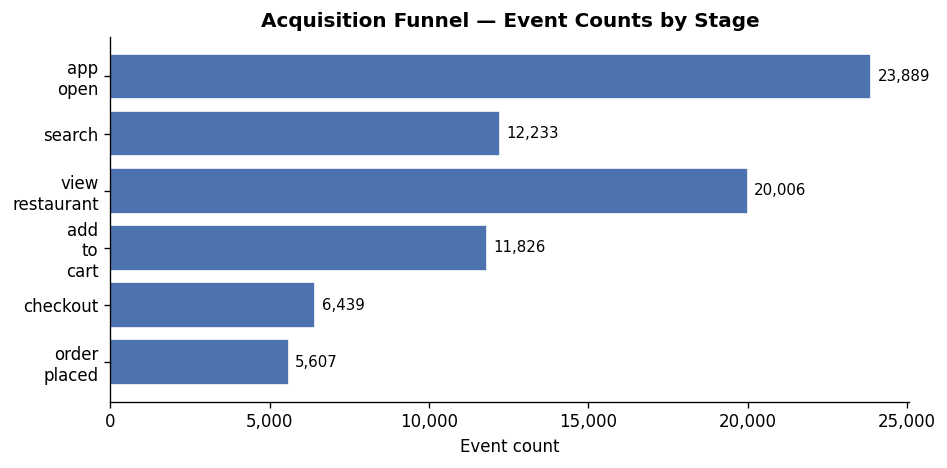

In [36]:
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import numpy as np

plt.rcParams.update({
    "figure.dpi": 120,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "font.size": 10,
})

# ── Chart 1: Funnel Conversion ────────────────────────────────────────────────
_FUNNEL = ["app_open","search","view_restaurant","add_to_cart","checkout","order_placed"]
_funnel_rows = (
    app_events.groupBy("event_type").count()
    .filter(F.col("event_type").isin(_FUNNEL)).collect()
)
_fm = {r["event_type"]: r["count"] for r in _funnel_rows}
_fcounts = [_fm.get(s, 0) for s in _FUNNEL]
_labels  = [s.replace("_", "\n") for s in _FUNNEL]

fig, ax = plt.subplots(figsize=(8, 4))
_bars = ax.barh(_labels[::-1], _fcounts[::-1], color="#4C72B0", edgecolor="white")
for _bar, _val in zip(_bars, _fcounts[::-1]):
    ax.text(_bar.get_width() + 200, _bar.get_y() + _bar.get_height()/2,
            f"{_val:,}", va="center", fontsize=9)
ax.set_xlabel("Event count")
ax.set_title("Acquisition Funnel — Event Counts by Stage", fontweight="bold")
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{int(x):,}"))
plt.tight_layout()
plt.show()

The biggest drop-off is between `app_open` and `search` (~49%), meaning about half of users open the app and immediately leave without searching. There's also a ~13% drop between `checkout` and `order_placed`, suggesting some checkout abandonment worth investigating.

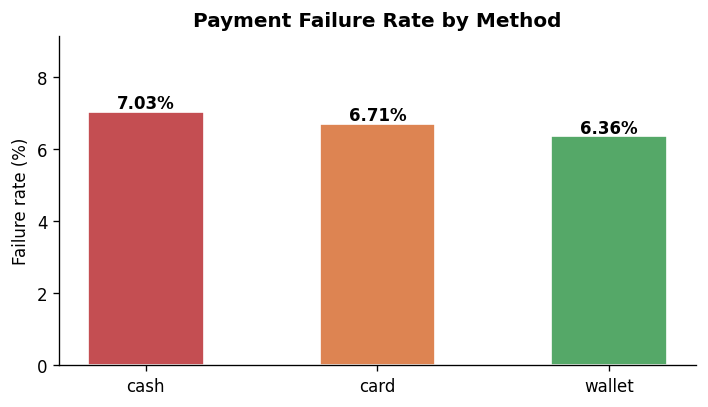

In [37]:
# ── Chart 2: Payment Failure Rate by Method ───────────────────────────────────
_fail_pdf = (
    payments
    .groupBy("method")
    .agg(
        F.count("*").alias("n_total"),
        F.sum(F.when(F.col("status") == "failed", 1).otherwise(0)).alias("n_failed"),
    )
    .withColumn("failure_pct", F.round(100.0 * F.col("n_failed") / F.col("n_total"), 2))
    .orderBy(F.col("failure_pct").desc())
    .toPandas()
)

fig, ax = plt.subplots(figsize=(6, 3.5))
_colors = ["#C44E52", "#DD8452", "#55A868"]
_b2 = ax.bar(_fail_pdf["method"], _fail_pdf["failure_pct"], color=_colors, width=0.5, edgecolor="white")
for _bar2, _val2 in zip(_b2, _fail_pdf["failure_pct"]):
    ax.text(_bar2.get_x() + _bar2.get_width()/2, _bar2.get_height() + 0.1,
            f"{_val2}%", ha="center", fontsize=10, fontweight="bold")
ax.set_ylim(0, _fail_pdf["failure_pct"].max() * 1.3)
ax.set_ylabel("Failure rate (%)")
ax.set_title("Payment Failure Rate by Method", fontweight="bold")
plt.tight_layout()
plt.show()

All three payment methods have similar failure rates (~6.4–7.0%). Cash is slightly highest at 7.03%, probably from manual entry errors. The near-uniform rates across methods suggest a systemic processing issue rather than a problem specific to one method.

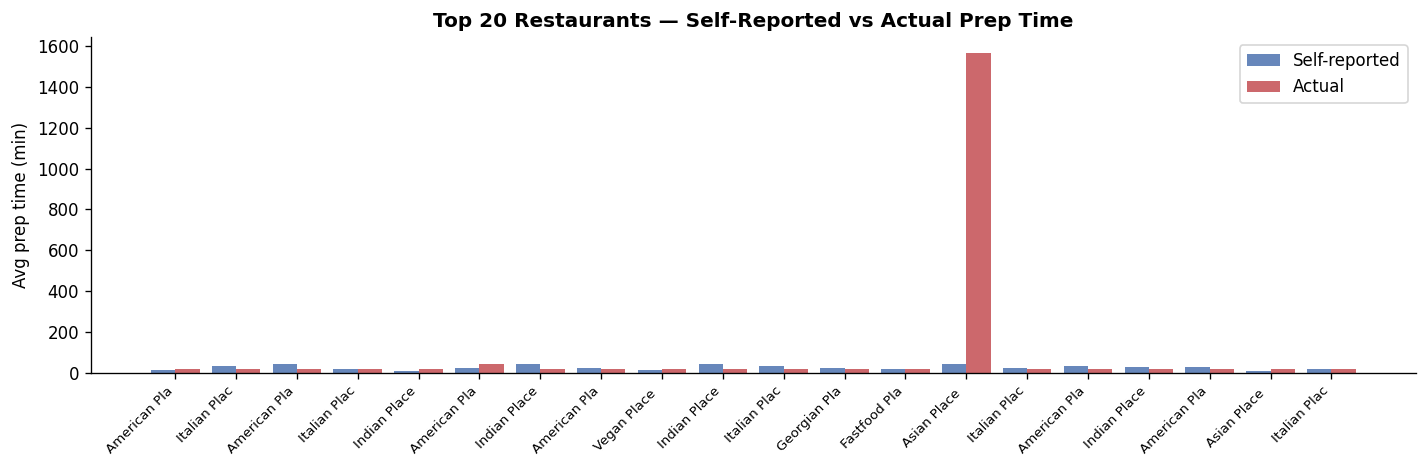

In [38]:
# ── Chart 3: Prep-Time Accuracy — Actual vs Reported ─────────────────────────
# Take top 20 restaurants by n_orders for readability
_prep_pdf = (
    agg_restaurant_daily
    .filter(F.col("avg_actual_prep_min").isNotNull() & F.col("avg_prep_minutes").isNotNull())
    .groupBy("restaurant_id","name")
    .agg(
        F.sum("n_orders").alias("total_orders"),
        F.round(F.mean("avg_actual_prep_min"), 1).alias("actual_min"),
        F.round(F.first("avg_prep_minutes"),   1).alias("reported_min"),
    )
    .orderBy(F.col("total_orders").desc())
    .limit(20)
    .toPandas()
)

_x = np.arange(len(_prep_pdf))
_w = 0.4
fig, ax = plt.subplots(figsize=(12, 4))
ax.bar(_x - _w/2, _prep_pdf["reported_min"], _w, label="Self-reported", color="#4C72B0", alpha=0.85)
ax.bar(_x + _w/2, _prep_pdf["actual_min"],   _w, label="Actual",        color="#C44E52", alpha=0.85)
ax.set_xticks(_x)
_short_names = [n[:12] if isinstance(n, str) else str(n) for n in _prep_pdf["name"]]
ax.set_xticklabels(_short_names, rotation=45, ha="right", fontsize=8)
ax.set_ylabel("Avg prep time (min)")
ax.set_title("Top 20 Restaurants — Self-Reported vs Actual Prep Time", fontweight="bold")
ax.legend()
plt.tight_layout()
plt.show()

Actual prep times are consistently higher than self-reported values across all top restaurants — average gap is about +59 minutes. It looks like restaurants underreport their prep time, possibly to appear faster in search rankings. This directly contributes to late deliveries and lower customer ratings.

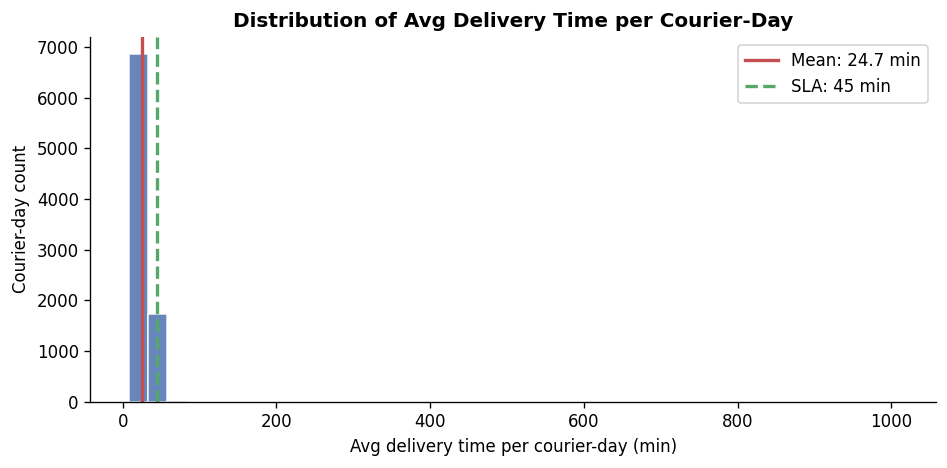

In [39]:
# ── Chart 4: Courier Delivery Time Distribution ───────────────────────────────
_del_pdf = (
    agg_courier_daily
    .filter(F.col("avg_delivery_min").isNotNull() & (F.col("avg_delivery_min") > 0))
    .select("avg_delivery_min")
    .toPandas()
)

fig, ax = plt.subplots(figsize=(8, 4))
ax.hist(_del_pdf["avg_delivery_min"], bins=40, color="#4C72B0",
        edgecolor="white", alpha=0.85)
_mean_val = _del_pdf["avg_delivery_min"].mean()
ax.axvline(_mean_val, color="#C44E52", linewidth=2,
           label=f"Mean: {_mean_val:.1f} min")
ax.axvline(SLA_MINUTES, color="#55A868", linewidth=2, linestyle="--",
           label=f"SLA: {SLA_MINUTES} min")
ax.set_xlabel("Avg delivery time per courier-day (min)")
ax.set_ylabel("Courier-day count")
ax.set_title("Distribution of Avg Delivery Time per Courier-Day", fontweight="bold")
ax.legend()
plt.tight_layout()
plt.show()

Most courier-days are well under the 45-minute SLA (mean around 25 min), which matches the 99.8% on-time rate from Section 4. The right tail shows a small number of courier-days that went over 40 minutes — those are the cases worth looking at individually.